# Salary Prediction — Exploratory Data Analysis

**Project:** Job & Career Intelligence Platform
**Use case:** Job Salary Prediction (regression)
**Purpose:** This notebook is an ANALYTICAL INVESTIGATION only. It does not
build the final feature-engineering pipeline or train the final model.
Its output is a frozen, evidence-backed specification that will later be
implemented in:

- `src/components/salary_feature_engineering.py`
- `src/configs/salary_feature_engineering_config.py`
- `src/entity/salary_feature_engineering_entity.py`

**Hard rules for this notebook:**
- Never overwrite `artifacts/feature_store/latest/feature_store.parquet`.
- Do not impute the salary target.
- Do not remove outliers before investigating them.
- Do not fit encoders/TF-IDF/scalers on the full dataset (train-only, later).
- Do not assume `normalized_salary` is safe without proving its derivation.
- Do not use salary-derived columns as predictors.
- Separate correlation from predictive usefulness from causal interpretation.
- Always ask: is this feature available at inference time?


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
FEATURE_STORE_PATH = "artifacts\\feature_store\\latest\\feature_store.parquet"
MIN_SUPPORT = 30  # minimum salary observations for a group to be reported


## Section 1 — Load and Verify Feature Store

Read-only load. We never write back to this file.

In [4]:
import os
from pathlib import Path

# Check if the file exists; if not, provide guidance
if not os.path.exists(FEATURE_STORE_PATH):
    feature_path = Path(FEATURE_STORE_PATH)
    if not feature_path.exists():
        for parent in [Path.cwd()] + list(Path.cwd().parents):
            candidate = parent / FEATURE_STORE_PATH
            if candidate.exists():
                feature_path = candidate
                break

    if not feature_path.exists():
        raise FileNotFoundError(
            f"Feature store not found at '{FEATURE_STORE_PATH}'. "
            f"Please ensure the file exists or update FEATURE_STORE_PATH to the correct location."
        )

    df = pd.read_parquet(feature_path)
    df_original_shape = df.shape

    print("Shape:", df.shape)
    display(df.head())
    display(df.tail())

# df = pd.read_parquet(FEATURE_STORE_PATH)
# df_original_shape = df.shape

# print("Shape:", df.shape)
# display(df.head())
# display(df.tail())


Shape: (154676, 65)


,title,description,location,views,applies,min_salary,med_salary,max_salary,pay_period,currency,compensation_type,normalized_salary,formatted_work_type,work_type,remote_allowed,formatted_experience_level,listed_time,original_listed_time,expiry,closed_time,sponsored,zip_code,fips,unmapped__job_posting_url,unmapped__application_url,unmapped__application_type,unmapped__skills_desc,unmapped__posting_domain,unmapped__scraped,company_name,company_description,company_size,company_state,company_country,company_city,company_zip_code,company_address,company_url,company_employee_count,company_follower_count,company_employee_count_recorded_at,listed_max_salary,listed_med_salary,listed_min_salary,listed_pay_period,listed_currency,listed_compensation_type,industry_count,top_industry,industry_list,skill_count,top_skill,skill_list,benefit_count,top_benefit,benefit_list,speciality_count,top_speciality,speciality_list,dataset_version,unmapped__company_name,salary_available,has_company_description,has_description,listing_age_available
0,Hearing Care Provider,Overview HearingLife is a national hearing car...,"Little River, SC",9,3,NaN,5250.00,NaN,monthly,usd,base_salary,NaN,full-time,full_time,True,entry level,2023-11-04 09:26:40,2023-11-04 09:26:40,2023-12-04 08:53:20,NaT,False,<NA>,NaN,https://www.linkedin.com/jobs/view/3757940104/...,https://careers-demant.icims.com/jobs/19601/he...,OffsiteApply,<NA>,careers-demant.icims.com,1.699138e+09,HearingLife,HearingLife is a national hearing care company...,5.0,new jersey,us,somerset,08873,580 Howard Avenue,https://www.linkedin.com/company/hearing-life,1171,11417,1.699131e+09,81100.0,5250.00,61110.0,MONTHLY,USD,BASE_SALARY,1,medical equipment manufacturing,MEDICAL_EQUIPMENT_MANUFACTURING,1,other,OTHER,2,disability insurance,DISABILITY_INSURANCE|MEDICAL_INSURANCE,10,audiologist,AUDIOLOGIST|BEHIND_EAR|DIGITAL_HEARING_INSTRUM...,Version_9,<NA>,True,True,True,True
1,Shipping & Receiving Associate 2nd shift (Beav...,Metalcraft of Mayville Metalcraft of Mayville ...,"Beaver Dam, WI",5,3,NaN,NaN,NaN,yearly,usd,base_salary,NaN,full-time,full_time,True,unknown,2023-11-04 06:40:00,2023-11-04 06:40:00,2023-12-04 08:53:20,NaT,False,<NA>,NaN,https://www.linkedin.com/jobs/view/3757940025/...,https://www.click2apply.net/mXLQz5S5NEYEXsKjwH...,OffsiteApply,<NA>,www.click2apply.net,1.699085e+09,"Metalcraft of Mayville, Inc.","Headquartered in Mayville, Wisconsin, Metalcra...",4.0,wi,us,mayville,53050,1000 Metalcraft Drive,https://www.linkedin.com/company/metalcraft-of...,300,2923,1.699085e+09,81100.0,26.00,61110.0,YEARLY,USD,BASE_SALARY,1,industrial machinery manufacturing,INDUSTRIAL_MACHINERY_MANUFACTURING,2,management,MANAGEMENT|MANUFACTURING,0,401(k),None,8,engineering,ENGINEERING|FORMING_AND_PIERCING|LASER_PLASMA_...,Version_9,<NA>,False,True,True,True
2,"Manager, Engineering",The TSUBAKI name is synonymous with excellence...,"Bessemer, AL",5,3,NaN,NaN,NaN,yearly,usd,base_salary,NaN,full-time,full_time,True,unknown,2023-11-04 06:40:00,2023-11-04 06:40:00,2023-12-04 08:53:20,NaT,False,<NA>,NaN,https://www.linkedin.com/jobs/view/3757938019/...,https://www.click2apply.net/LwbOykH2yAJdahB5Ah...,OffsiteApply,Bachelor's Degree in Mechanical Engineering pr...,www.click2apply.net,1.699086e+09,"U.S. Tsubaki Power Transmission, LLC","U.S. Tsubaki Power Transmission, LLC is a subs...",4.0,illinois,us,wheeling,60090,301E Marquardt Drive,https://www.linkedin.com/company/u.s.-tsubaki-...,314,8487,1.699086e+09,81100.0,26.00,61110.0,YEARLY,USD,BASE_SALARY,1,automation machinery manufacturing,AUTOMATION_MACHINERY_MANUFACTURING,1,engineering,ENGINEERING,0,401(k),None,7,automotive,AUTOMOTIVE|CABLE_HOSE_CARRIER_SYSTEMS|CONVEYOR...,Version_9,<NA>,False,True,True,True
3,Cook,descriptionTitle Looking for a great opportuni...,"Aliso Viejo, CA",1,3,NaN,22.27,NaN,hourly,usd,base_salary,NaN,full-time,full_time,True,entry level,2023-11-04 06:40:00,2023-11-04 06:40:00,2023-12-04 08:53:20,NaT,False,<NA>,NaN,https://www.linkedin.com/jobs/view/3757

,title,description,location,views,applies,min_salary,med_salary,max_salary,pay_period,currency,compensation_type,normalized_salary,formatted_work_type,work_type,remote_allowed,formatted_experience_level,listed_time,original_listed_time,expiry,closed_time,sponsored,zip_code,fips,unmapped__job_posting_url,unmapped__application_url,unmapped__application_type,unmapped__skills_desc,unmapped__posting_domain,unmapped__scraped,company_name,company_description,company_size,company_state,company_country,company_city,company_zip_code,company_address,company_url,company_employee_count,company_follower_count,company_employee_count_recorded_at,listed_max_salary,listed_med_salary,listed_min_salary,listed_pay_period,listed_currency,listed_compensation_type,industry_count,top_industry,industry_list,skill_count,top_skill,skill_list,benefit_count,top_benefit,benefit_list,speciality_count,top_speciality,speciality_list,dataset_version,unmapped__company_name,salary_available,has_company_description,has_description,listing_age_available
154671,Title IX/Investigations Attorney,Our Walnut Creek office is currently seeking a...,"Walnut Creek, CA",1,3,120000.0,NaN,195000.0,yearly,usd,base_salary,157500.0,full-time,full_time,True,mid-senior level,2024-04-20 00:00:23,2024-04-20 00:00:23,2024-05-20 00:00:23,NaT,False,94595.0,6013.0,https://www.linkedin.com/jobs/view/3906267117/...,<NA>,ComplexOnsiteApply,<NA>,<NA>,1.698996e+09,Lozano Smith,"For more than 30 years, Lozano Smith has serve...",2.0,california,us,fresno,93720,7404 N Spalding Ave,https://www.linkedin.com/company/lozano-smith,185,2818,1.713570e+09,195000.0,26.0,120000.0,YEARLY,USD,BASE_SALARY,1,law practice,LAW_PRACTICE,2,business development,BUSINESS_DEVELOPMENT|LEGAL,6,401(k),401_K|DENTAL_INSURANCE|MEDICAL_INSURANCE|PAID_...,5,education law,EDUCATION_LAW|LABOR_AND_EMPLOYMENT_LAW|LOCAL_G...,Version_13,Lozano Smith,True,True,True,True
154672,"Staff Software Engineer, ML Serving Platform",About Pinterest: Millions of people across the...,United States,3,3,NaN,NaN,NaN,yearly,usd,base_salary,NaN,full-time,full_time,True,mid-senior level,2024-04-20 00:17:16,2024-04-20 00:05:00,2024-05-20 00:17:16,NaT,False,<NA>,NaN,https://www.linkedin.com/jobs/view/3906267126/...,https://www.pinterestcareers.com/en/jobs/58824...,OffsiteApply,<NA>,www.pinterestcareers.com,1.698996e+09,Pinterest,Pinterest's mission is to bring everyone the i...,5.0,california,us,san francisco,0,505 Brannan St,https://www.linkedin.com/company/pinterest,8749,853793,1.713572e+09,81100.0,26.0,61110.0,YEARLY,USD,BASE_SALARY,3,it services and it consulting,IT_SERVICES_AND_IT_CONSULTING|SOFTWARE_DEVELOP...,2,engineering,ENGINEERING|INFORMATION_TECHNOLOGY,0,401(k),None,0,<NA>,None,Version_13,Pinterest,False,True,True,True
154673,"Account Executive, Oregon/Washington",Company Overview EPS Learning is a leading K–1...,"Spokane, WA",3,3,NaN,NaN,NaN,yearly,usd,base_salary,NaN,full-time,full_time,True,mid-senior level,2024-04-20 00:18:59,2024-04-20 00:07:02,2024-05-20 00:18:59,NaT,False,99201.0,53063.0,https://www.linkedin.com/jobs/view/3906267131/...,https://epsoperations.bamboohr.com/careers/122...,OffsiteApply,<NA>,epsoperations.bamboohr.com,1.698996e+09,EPS Learning,EPS Learning has partnered with educators for ...,2.0,md,us,bethesda,20814,4800 Hampden Ln,https://www.linkedin.com/company/epslearning,127,2047,1.713572e+09,81100.0,26.0,61110.0,YEARLY,USD,BASE_SALARY,1,education administration programs,EDUCATION_ADMINISTRATION_PROGRAMS,2,business development,BUSINESS_DEVELOPMENT|SALES,0,401(k),None,0,<NA>,None,Version_13,EPS Learning,False,True,True,True
154674,Business Development Manager,The Business Development Manager is a 'hunter'...,"Texas, United States",4,3,NaN,NaN,NaN,yearly,usd,base_salary,NaN,full-time,full_time,True,unknown,2024-04-20 00:23:52,2024-04-20 00:23:52,2024-05-20 00:23:52,NaT,False,<NA>,NaN,https://www.linkedin.com/jobs/view/3906267195/...,<NA>,ComplexOnsiteApply,<NA>,<NA>,1.698996e+09,Trelleborg Applied Technologies,Trell

In [5]:
df.info(memory_usage="deep")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154676 entries, 0 to 154675
Data columns (total 65 columns):
 #   Column                              Non-Null Count   Dtype         
---  ------                              --------------   -----         
 0   title                               154676 non-null  object        
 1   description                         154676 non-null  object        
 2   location                            154676 non-null  object        
 3   views                               154676 non-null  Int64         
 4   applies                             154676 non-null  Int64         
 5   min_salary                          40243 non-null   float64       
 6   med_salary                          8436 non-null    float64       
 7   max_salary                          40243 non-null   float64       
 8   pay_period                          154676 non-null  category      
 9   currency                            154676 non-null  category      
 10  compensa

In [6]:
print("Columns:", list(df.columns))
dtype_table = df.dtypes.rename("dtype").to_frame()
display(dtype_table)

dup_cols = df.columns[df.columns.duplicated()].tolist()
print("Duplicate column names:", dup_cols)

mem_mb = df.memory_usage(deep=True).sum() / 1e6
print(f"Total memory usage: {mem_mb:,.1f} MB")

exact_dup_rows = df.duplicated().sum()
print(f"Exact duplicate rows: {exact_dup_rows:,}")


Columns: ['title', 'description', 'location', 'views', 'applies', 'min_salary', 'med_salary', 'max_salary', 'pay_period', 'currency', 'compensation_type', 'normalized_salary', 'formatted_work_type', 'work_type', 'remote_allowed', 'formatted_experience_level', 'listed_time', 'original_listed_time', 'expiry', 'closed_time', 'sponsored', 'zip_code', 'fips', 'unmapped__job_posting_url', 'unmapped__application_url', 'unmapped__application_type', 'unmapped__skills_desc', 'unmapped__posting_domain', 'unmapped__scraped', 'company_name', 'company_description', 'company_size', 'company_state', 'company_country', 'company_city', 'company_zip_code', 'company_address', 'company_url', 'company_employee_count', 'company_follower_count', 'company_employee_count_recorded_at', 'listed_max_salary', 'listed_med_salary', 'listed_min_salary', 'listed_pay_period', 'listed_currency', 'listed_compensation_type', 'industry_count', 'top_industry', 'industry_list', 'skill_count', 'top_skill', 'skill_list', 'benef

,dtype
title,object
description,object
location,object
views,Int64
applies,Int64
...,...
unmapped__company_name,string[python]
salary_available,boolean
has_company_description,boolean
has_description,boolean


Duplicate column names: []
Total memory usage: 1,608.6 MB
Exact duplicate rows: 0


In [7]:
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null_count": df.notna().sum(),
    "null_count": df.isna().sum(),
    "null_percentage": (df.isna().mean() * 100).round(2),
    "unique_count": df.nunique(dropna=True),
})
summary["unique_percentage"] = (summary["unique_count"] / len(df) * 100).round(2)

summary_by_null = summary.sort_values("null_percentage", ascending=False)
summary_by_unique = summary.sort_values("unique_count", ascending=False)

display(summary_by_null)
display(summary_by_unique)


,dtype,non_null_count,null_count,null_percentage,unique_count,unique_percentage
closed_time,datetime64[ns],2205,152471,98.57,684,0.44
unmapped__skills_desc,string,2772,151904,98.21,2506,1.62
med_salary,float64,8436,146240,94.55,1703,1.10
normalized_salary,float64,35563,119113,77.01,7235,4.68
benefit_list,object,39974,114702,74.16,442,0.29
...,...,...,...,...,...,...
dataset_version,object,154676,0,0.00,2,0.00
salary_available,boolean,154676,0,0.00,2,0.00
has_company_description,boolean,154676,0,0.00,1,0.00
has_description,boolean,154676,0,0.00,1,0.00


,dtype,non_null_count,null_count,null_percentage,unique_count,unique_percentage
unmapped__job_posting_url,string,154676,0,0.00,154676,100.00
description,object,154676,0,0.00,134852,87.18
unmapped__application_url,string,108026,46650,30.16,104565,67.60
title,object,154676,0,0.00,89189,57.66
original_listed_time,datetime64[ns],154676,0,0.00,64156,41.48
...,...,...,...,...,...,...
remote_allowed,boolean,154676,0,0.00,1,0.00
listed_compensation_type,string,154676,0,0.00,1,0.00
has_company_description,boolean,154676,0,0.00,1,0.00
has_description,boolean,154676,0,0.00,1,0.00


**Interpretation:** This is a structural inventory only — no columns are
removed here. Use `summary_by_null` to prioritize missing-value strategy later
(Section 26) and `summary_by_unique` to plan encoding strategy (Section 31).

**Decision:** No action yet. Proceed to targeted salary investigation.

## Section 2 — Salary Column Audit

Raw-reality check on every salary-related column. No outlier removal here.

In [8]:
SALARY_NUM_COLS = [
    "min_salary", "med_salary", "max_salary", "normalized_salary",
    "listed_min_salary", "listed_med_salary", "listed_max_salary",
]
SALARY_CAT_COLS = [
    "pay_period", "listed_pay_period", "currency", "listed_currency",
    "compensation_type", "listed_compensation_type", "salary_available",
]

pcts = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999]

def salary_col_report(s: pd.Series) -> dict:
    s_num = pd.to_numeric(s, errors="coerce")
    q = s_num.quantile(pcts)
    return {
        "count": s_num.notna().sum(),
        "missing_count": s_num.isna().sum(),
        "missing_pct": round(s_num.isna().mean() * 100, 2),
        "min": s_num.min(),
        **{f"p{int(p*1000)/10}": q[p] for p in pcts},
        "max": s_num.max(),
        "mean": s_num.mean(),
        "std": s_num.std(),
        "n_zero": int((s_num == 0).sum()),
        "n_negative": int((s_num < 0).sum()),
    }

salary_audit = pd.DataFrame({c: salary_col_report(df[c]) for c in SALARY_NUM_COLS if c in df.columns}).T
display(salary_audit)


,count,missing_count,missing_pct,min,p1.0,p5.0,p10.0,p25.0,p50.0,p75.0,p90.0,p95.0,p99.0,p99.5,p99.9,max,mean,std,n_zero,n_negative
min_salary,40243.0,114433.0,73.98,1.0,13.50,16.8110,19.5,38.63,61110.0,100000.0,140000.0,165000.0,240000.0,270000.00000,4.151600e+05,8.500000e+07,64479.135877,4.277945e+05,0.0,0.0
med_salary,8436.0,146240.0,94.55,0.0,12.00,15.0000,16.0,18.85,26.0,5000.0,85000.0,130000.0,250000.0,344287.65000,7.500000e+05,9.984260e+05,24762.269162,6.006787e+04,15.0,0.0
max_salary,40243.0,114433.0,73.98,1.0,16.00,20.0000,24.7,50.00,81000.0,140000.0,200000.0,243300.0,350000.0,438950.00000,7.500000e+05,1.200000e+08,91389.702664,6.049060e+05,0.0,0.0
normalized_salary,35563.0,119113.0,77.01,0.0,134.05,33280.0000,38480.0,52000.00,81850.0,125000.0,168500.0,200000.0,300918.0,393500.00000,1.390265e+06,5.356000e+08,207007.149099,5.134025e+06,14.0,0.0
listed_min_salary,154676.0,0.0,0.00,1.0,16.00,26.9425,40000.0,61110.00,61110.0,61110.0,78000.0,111000.0,175000.0,200000.00000,2.878880e+05,8.500000e+07,61986.568667,2.182101e+05,0.0,0.0
listed_med_salary,154676.0,0.0,0.00,0.0,17.50,26.0000,26.0,26.00,26.0,26.0,26.0,26.0,55000.0,90945.57625,2.011820e+05,9.984260e+05,1375.111476,1.511019e+04,15.0,0.0
listed_max_salary,154676.0,0.0,0.00,1.0,19.50,35.0000,53000.0,81100.00,81100.0,81100.0,105000.0,158230.0,255017.5,302400.00000,5.000000e+05,7.000090e+09,129758.704029,1.780313e+07,0.0,0.0


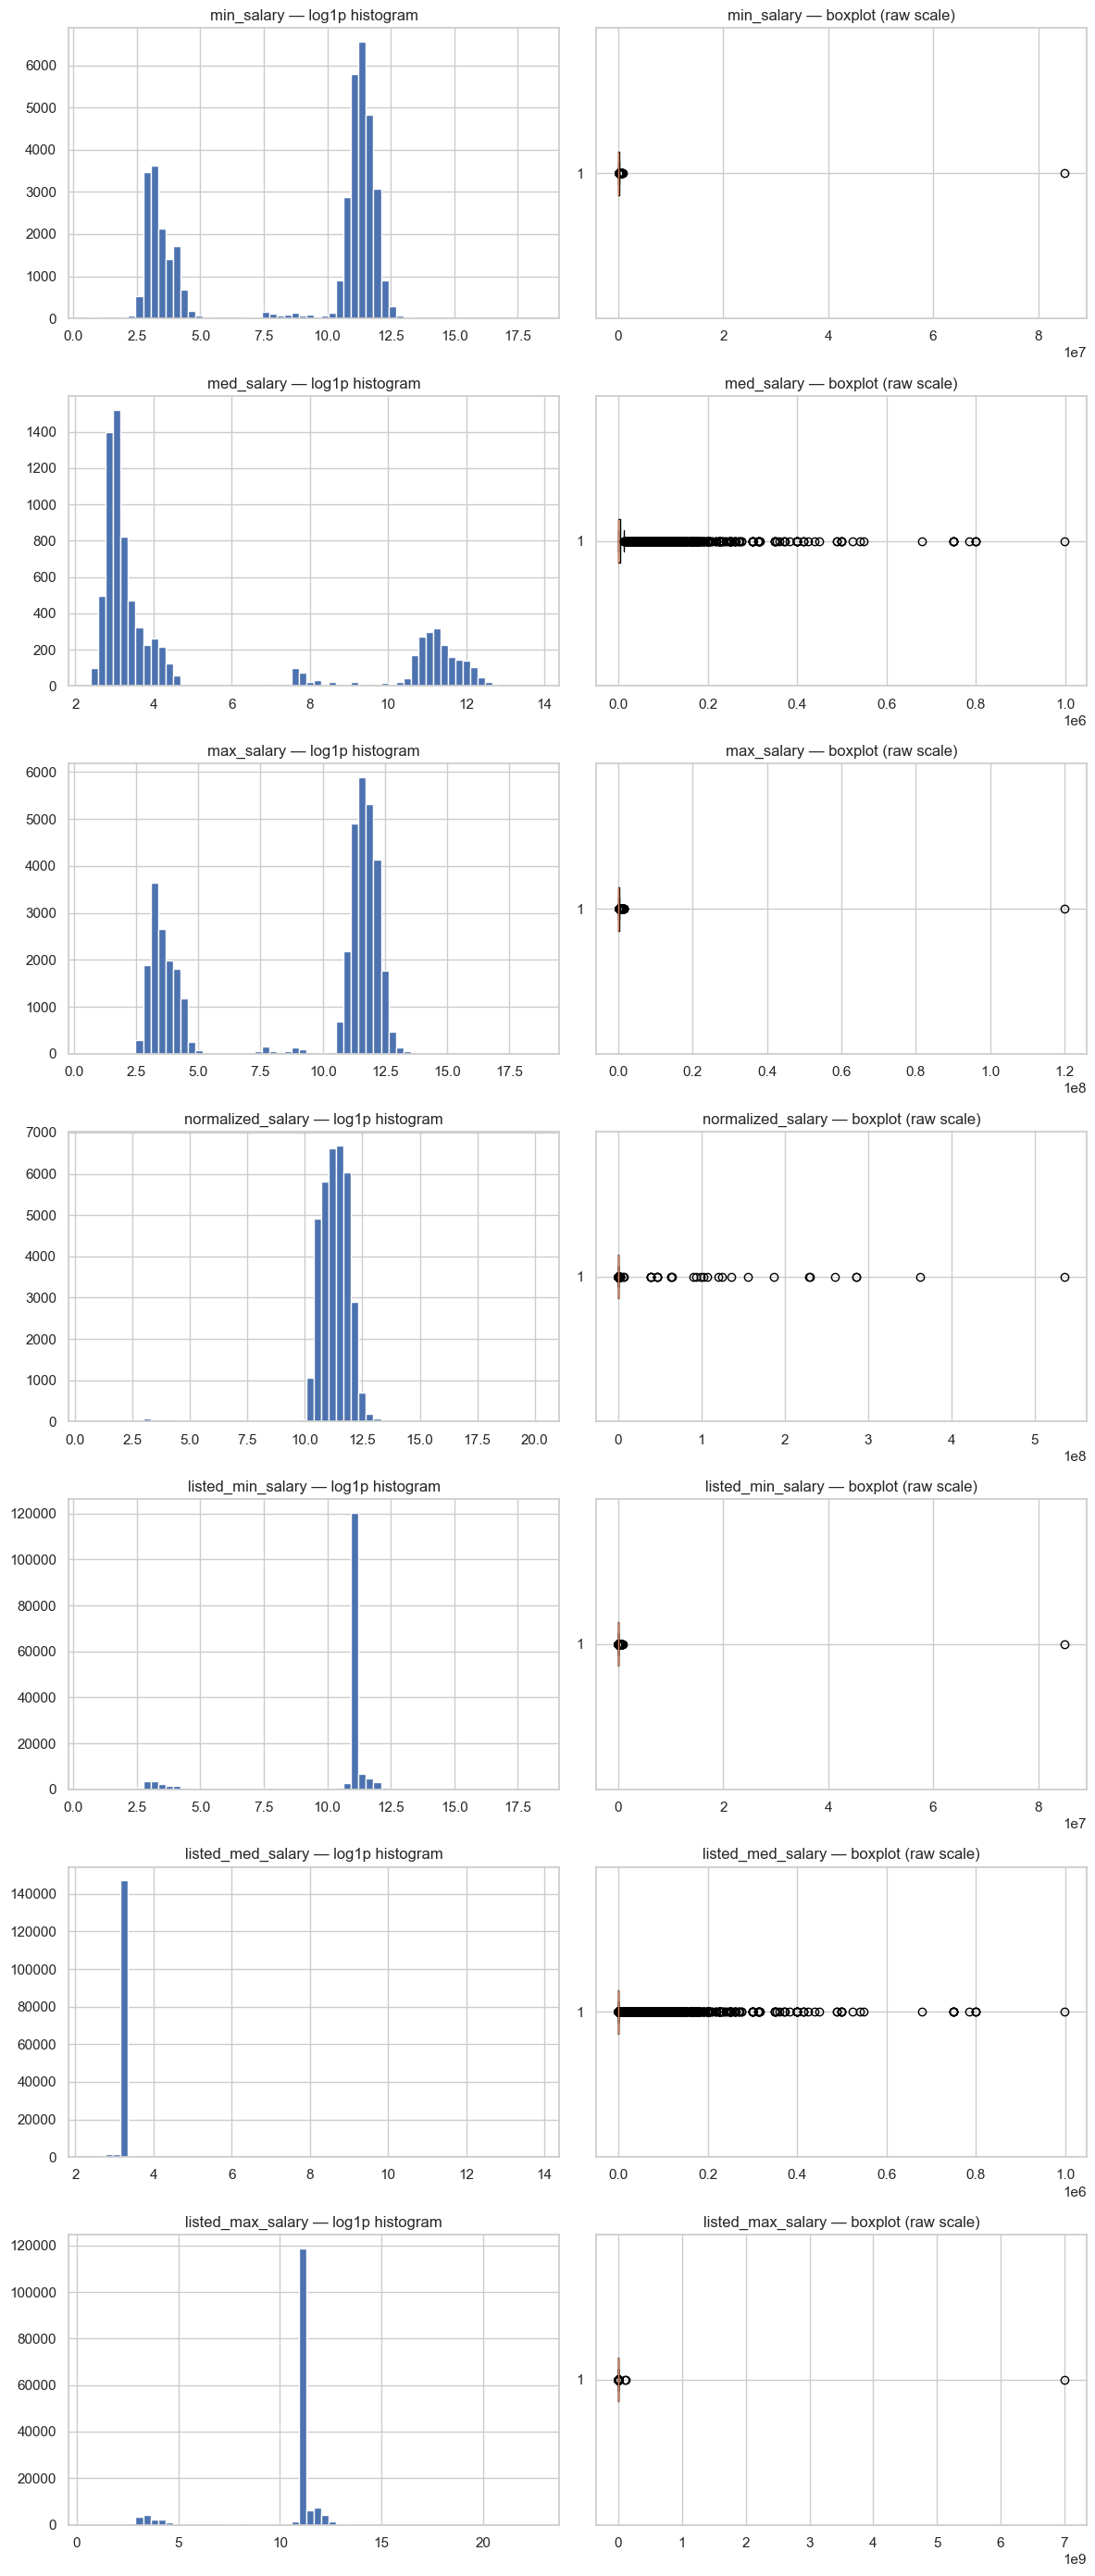

In [9]:
fig, axes = plt.subplots(len(SALARY_NUM_COLS), 2, figsize=(12, 4 * len(SALARY_NUM_COLS)))
for i, c in enumerate(SALARY_NUM_COLS):
    if c not in df.columns:
        continue
    vals = pd.to_numeric(df[c], errors="coerce").dropna()
    vals_pos = vals[vals > 0]
    axes[i, 0].hist(np.log1p(vals_pos), bins=60)
    axes[i, 0].set_title(f"{c} — log1p histogram")
    axes[i, 1].boxplot(vals, vert=False, showfliers=True)
    axes[i, 1].set_title(f"{c} — boxplot (raw scale)")
plt.tight_layout()
plt.show()


In [10]:
display(df["pay_period"].value_counts(dropna=False))

pay_period
yearly      134185
hourly       19500
monthly        722
weekly         259
biweekly         9
once             1
Name: count, dtype: int64

In [11]:
display(df["listed_pay_period"].value_counts(dropna=False))

listed_pay_period
YEARLY      134185
HOURLY       19500
MONTHLY        722
WEEKLY         259
BIWEEKLY         9
ONCE             1
Name: count, dtype: Int64

In [12]:
display(df["currency"].value_counts(dropna=False))

currency
usd    154663
eur         6
cad         3
bbd         2
gbp         2
Name: count, dtype: int64

In [13]:
display(df["listed_currency"].value_counts(dropna=False))

listed_currency
USD    154663
EUR         6
CAD         3
BBD         2
GBP         2
Name: count, dtype: Int64

In [14]:
display(df["compensation_type"].value_counts(dropna=False))

compensation_type
base_salary    154676
Name: count, dtype: int64

In [15]:
display(df["listed_compensation_type"].value_counts(dropna=False))

listed_compensation_type
BASE_SALARY    154676
Name: count, dtype: Int64

In [16]:
display(df["salary_available"].value_counts(dropna=False))

salary_available
False    105997
True      48679
Name: count, dtype: Int64

**Interpretation:** Confirms the data dictionary's claims — `min_salary`/
`max_salary` are ~74% missing, `med_salary` ~94.5% missing, `normalized_salary`
~77% missing, while `listed_*` fields are 0% missing. Raw histograms will show
heavy right-skew and extreme tails (values into the tens/hundreds of millions),
confirming unit/currency-mixing errors exist — but nothing is removed yet.

**Decision:** Carry all salary columns forward unmodified into Sections 3–4
for relationship testing.

## Section 3 — Verify Salary Field Relationships

Test the hypothesis: `min_salary`/`max_salary` (range) and `med_salary`
(single value) are mutually exclusive, and `salary_available` is exactly
their union.

In [17]:
min_present = df["min_salary"].notna()
max_present = df["max_salary"].notna()
med_present = df["med_salary"].notna()

report = {
    "min AND max present": int((min_present & max_present).sum()),
    "min present, max missing": int((min_present & ~max_present).sum()),
    "min missing, max present": int((~min_present & max_present).sum()),
    "med present": int(med_present.sum()),
    "(min&max) AND med present simultaneously": int((min_present & max_present & med_present).sum()),
    "all three missing": int((~min_present & ~max_present & ~med_present).sum()),
    "salary_available == True": int((df["salary_available"] == True).sum()),
    "salary_available == False": int((df["salary_available"] == False).sum()),
}
display(pd.Series(report, name="count").to_frame())


,count
min AND max present,40243
"min present, max missing",0
"min missing, max present",0
med present,8436
(min&max) AND med present simultaneously,0
all three missing,105997
salary_available == True,48679
salary_available == False,105997


In [18]:
has_range = min_present & max_present
has_med = med_present
crosstab = pd.crosstab(has_range, has_med, rownames=["has_range"], colnames=["has_med"])
display(crosstab)

union = has_range | has_med
match = (union == df["salary_available"])
print(f"salary_available exactly equals (range OR med) for {match.mean()*100:.2f}% of rows")
exceptions = df.loc[~match, ["min_salary", "max_salary", "med_salary", "salary_available"]]
print(f"Exception rows: {len(exceptions):,}")
display(exceptions.head(20))


has_med,False,True
has_range,,
False,105997,8436
True,40243,0


salary_available exactly equals (range OR med) for 100.00% of rows
Exception rows: 0


,min_salary,max_salary,med_salary,salary_available


**Interpretation:** State plainly whether range and median salary are truly
mutually exclusive (crosstab off-diagonal should be ~0), and whether
`salary_available` is a perfect OR-flag or has exceptions (shown above).

**Decision:** If exceptions are negligible (<0.1%), treat `salary_available`
as a reliable derived flag and proceed with the range/median coalesce logic
from the previous pipeline draft. If exceptions are non-trivial, investigate
those rows individually before freezing the target-construction rule.

## Section 4 — Verify `normalized_salary`

Do not assume it's derived — prove it mathematically against
`range_midpoint`, `med_salary`, and `pay_period`.

In [19]:
range_midpoint = (df["min_salary"] + df["max_salary"]) / 2

compare = pd.DataFrame({
    "range_midpoint": range_midpoint,
    "med_salary": df["med_salary"],
    "normalized_salary": df["normalized_salary"],
    "pay_period": df["pay_period"],
})

# Where we have both range_midpoint and normalized_salary
both_range = compare.dropna(subset=["range_midpoint", "normalized_salary"])
both_med = compare.dropna(subset=["med_salary", "normalized_salary"])

print("Rows with range_midpoint & normalized_salary:", len(both_range))
print("Rows with med_salary & normalized_salary:", len(both_med))

if len(both_range):
    corr_range = both_range["range_midpoint"].corr(both_range["normalized_salary"])
    print(f"Correlation(range_midpoint, normalized_salary): {corr_range:.4f}")
if len(both_med):
    corr_med = both_med["med_salary"].corr(both_med["normalized_salary"])
    print(f"Correlation(med_salary, normalized_salary): {corr_med:.4f}")


Rows with range_midpoint & normalized_salary: 29338
Rows with med_salary & normalized_salary: 6225
Correlation(range_midpoint, normalized_salary): 0.1075
Correlation(med_salary, normalized_salary): 0.6719


In [20]:
ANNUAL_MULT = {"yearly": 1, "monthly": 12, "biweekly": 26, "weekly": 52, "hourly": 2080}

for period, mult in ANNUAL_MULT.items():
    sub = both_range[both_range["pay_period"].astype(str).str.lower() == period]
    if len(sub) == 0:
        continue
    implied_annual = sub["range_midpoint"] * mult
    ratio = (sub["normalized_salary"] / sub["range_midpoint"]).median()
    print(f"{period:>10s} (n={len(sub):>6,}): normalized/raw median ratio = {ratio:.2f}  "
          f"(annualization multiplier would be {mult})")

print("\nSample rows by pay_period:")
for period in df["pay_period"].dropna().astype(str).str.lower().unique():
    sample = compare[compare["pay_period"].astype(str).str.lower() == period].dropna(
        subset=["normalized_salary"]).head(3)
    print(f"\n--- {period} ---")
    display(sample)


    yearly (n=18,825): normalized/raw median ratio = 1.00  (annualization multiplier would be 1)
   monthly (n=   276): normalized/raw median ratio = 12.00  (annualization multiplier would be 12)
  biweekly (n=     9): normalized/raw median ratio = 26.00  (annualization multiplier would be 26)
    weekly (n=   177): normalized/raw median ratio = 52.00  (annualization multiplier would be 52)
    hourly (n=10,051): normalized/raw median ratio = 2080.00  (annualization multiplier would be 2080)

Sample rows by pay_period:

--- monthly ---


,range_midpoint,med_salary,normalized_salary,pay_period
32551,NaN,350.0,4200.0,monthly
32570,4439.0,NaN,53268.0,monthly
32632,NaN,4200.0,50400.0,monthly



--- yearly ---


,range_midpoint,med_salary,normalized_salary,pay_period
32546,55000.0,NaN,55000.0,yearly
32547,157500.0,NaN,157500.0,yearly
32549,180000.0,NaN,180000.0,yearly



--- hourly ---


...

,range_midpoint,med_salary,normalized_salary,pay_period
42195,1840.90,NaN,95726.80,weekly
42198,3068.16,NaN,159544.32,weekly
42199,2196.40,NaN,114212.80,weekly



--- once ---


,range_midpoint,med_salary,normalized_salary,pay_period



--- biweekly ---


,range_midpoint,med_salary,normalized_salary,pay_period
68783,2057.0,NaN,53482.0,biweekly
118040,2134.0,NaN,55484.0,biweekly
118175,60492.5,NaN,1572805.0,biweekly


In [21]:
diff_range = (both_range["normalized_salary"] - both_range["range_midpoint"]).abs()
pct_close_raw = (diff_range < 1).mean() * 100
print(f"% rows where normalized_salary == raw range_midpoint (no transform): {pct_close_raw:.2f}%")

# NORMALIZED_SALARY_STATUS decision printed after inspecting the above output
print("NORMALIZED_SALARY_STATUS: <fill in from evidence above: SAFE_TARGET / DERIVED_TARGET / UNRELIABLE / UNKNOWN>")


% rows where normalized_salary == raw range_midpoint (no transform): 64.17%
NORMALIZED_SALARY_STATUS: <fill in from evidence above: SAFE_TARGET / DERIVED_TARGET / UNRELIABLE / UNKNOWN>


**Interpretation:** Based on the ratio table and correlation values above:
if `normalized_salary` tracks `range_midpoint`/`med_salary` closely (ratio ≈
the pay-period multiplier, correlation ≈ 1) it is a **DERIVED_TARGET** — safe
to use as a sanity check but not a source of *new* information, and it should
NOT be separately imputed (imputing it would just be re-deriving noise). If
the ratios are inconsistent across pay periods or correlation is weak, mark it
**UNRELIABLE** and exclude it from the model entirely, relying only on the
`candidate_annual_salary` we construct ourselves in Section 7.

**Decision:** `normalized_salary` is dropped as a predictor and as a target
either way — it is fully covered by `min/med/max_salary` + `pay_period`,
which we build the target from directly and transparently.

## Section 5 — Pay Period Investigation

In [22]:
pp_counts = df["pay_period"].value_counts(dropna=False)
pp_pct = (pp_counts / len(df) * 100).round(2)
display(pd.DataFrame({"count": pp_counts, "pct": pp_pct}))

has_salary = df["min_salary"].notna() | df["max_salary"].notna() | df["med_salary"].notna()
by_period = df.assign(has_salary=has_salary, raw_val=range_midpoint.fillna(df["med_salary"])).groupby(
    df["pay_period"].astype(str), dropna=False)

pp_summary = by_period.agg(
    total=("has_salary", "size"),
    salary_present=("has_salary", "sum"),
    median_raw_salary=("raw_val", "median"),
    mean_raw_salary=("raw_val", "mean"),
)
pp_summary["disclosure_rate_pct"] = (pp_summary["salary_present"] / pp_summary["total"] * 100).round(2)
display(pp_summary)


,count,pct
pay_period,,
yearly,134185,86.75
hourly,19500,12.61
monthly,722,0.47
weekly,259,0.17
biweekly,9,0.01
once,1,0.00


,total,salary_present,median_raw_salary,mean_raw_salary,disclosure_rate_pct
pay_period,,,,,
biweekly,9,9,60492.50,48025.444444,100.00
hourly,19500,19500,25.00,143.542128,100.00
monthly,722,722,4639.00,5326.422230,100.00
once,1,1,68.00,68.000000,100.00
weekly,259,259,2093.04,2074.134247,100.00
yearly,134185,28188,102400.00,118404.820890,21.01


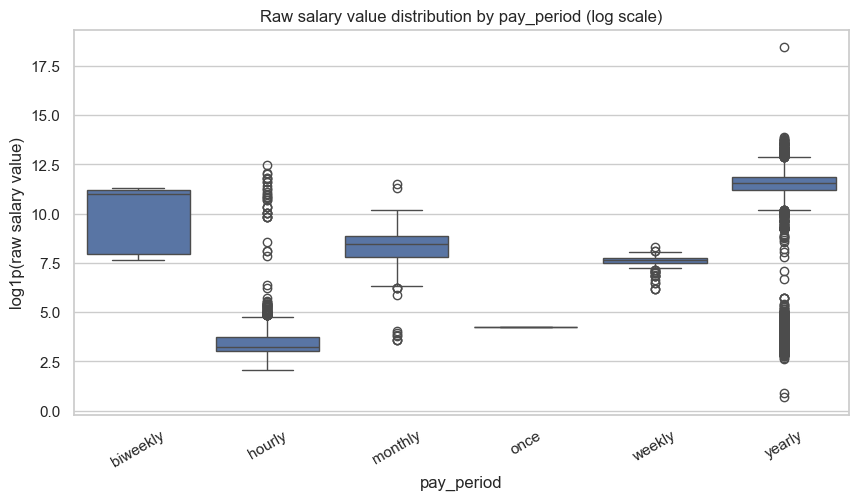

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = df.assign(raw_val=range_midpoint.fillna(df["med_salary"]))
plot_df = plot_df[plot_df["raw_val"].notna() & (plot_df["raw_val"] > 0)]
sns.boxplot(data=plot_df, x="pay_period", y=np.log1p(plot_df["raw_val"]), ax=ax)
ax.set_ylabel("log1p(raw salary value)")
ax.set_title("Raw salary value distribution by pay_period (log scale)")
plt.xticks(rotation=30)
plt.show()


In [24]:
hourly = plot_df[plot_df["pay_period"].astype(str).str.lower() == "hourly"]
print("Hourly raw value stats:")
display(hourly["raw_val"].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]))
print("\nHourly values implying > $500/hr (likely already-annual figures mislabeled hourly):")
display(hourly[hourly["raw_val"] > 500].head(10))

once_count = (df["pay_period"].astype(str).str.lower() == "once").sum()
unknown_period = df["pay_period"].isna().sum()
print(f"\n'once' pay_period rows: {once_count:,}")
print(f"missing pay_period rows: {unknown_period:,}")


Hourly raw value stats:


count     19500.000000
mean        143.542128
std        3581.619567
min           7.000000
1%           12.800000
5%           15.000000
25%          19.500000
50%          25.000000
75%          41.000000
95%          73.500000
99%          97.500000
max      257500.000000
Name: raw_val, dtype: float64


Hourly values implying > $500/hr (likely already-annual figures mislabeled hourly):


,title,description,location,views,applies,min_salary,med_salary,max_salary,pay_period,currency,compensation_type,normalized_salary,formatted_work_type,work_type,remote_allowed,formatted_experience_level,listed_time,original_listed_time,expiry,closed_time,sponsored,zip_code,fips,unmapped__job_posting_url,unmapped__application_url,unmapped__application_type,unmapped__skills_desc,unmapped__posting_domain,unmapped__scraped,company_name,company_description,company_size,company_state,company_country,company_city,company_zip_code,company_address,company_url,company_employee_count,company_follower_count,company_employee_count_recorded_at,listed_max_salary,listed_med_salary,listed_min_salary,listed_pay_period,listed_currency,listed_compensation_type,industry_count,top_industry,industry_list,skill_count,top_skill,skill_list,benefit_count,top_benefit,benefit_list,speciality_count,top_speciality,speciality_list,dataset_version,unmapped__company_name,salary_available,has_company_description,has_description,listing_age_available,raw_val
6522,Administrative Assistant (Operations Support),"Position Title: Administrative Assistant, Oper...","New York, NY",23,2,NaN,5244.67,NaN,hourly,usd,base_salary,NaN,full-time,full_time,True,unknown,2023-11-03 19:33:20,2023-11-03 19:33:20,2024-05-01 19:00:00,NaT,True,<NA>,NaN,https://www.linkedin.com/jobs/view/3757461077/...,https://eur02.safelinks.protection.outlook.com...,OffsiteApply,<NA>,<NA>,1.699046e+09,IOM-USRAP DC,The United States Refugee Admissions Program (...,7.0,district of columbia,us,washington,20016,1625 Massachusetts Ave,https://www.linkedin.com/company/iom-usrap-dc,10,1645,1.699043e+09,81100.0,5244.67,61110.0,HOURLY,USD,BASE_SALARY,1,non-profit organizations,NON_PROFIT_ORGANIZATIONS,0,management,None,7,401(k),401_K|DENTAL_INSURANCE|MEDICAL_INSURANCE|PAID_...,0,<NA>,None,Version_9,<NA>,True,True,True,True,5244.67
14517,Accounts Payable Specialist,"Schaumburg, IL (50% Remote 50% Onsite) TouchTu...","Schaumburg, IL",9,3,50000.0,NaN,52000.0,hourly,usd,base_salary,NaN,full-time,full_time,True,entry level,2023-11-03 22:20:00,2023-11-03 22:20:00,2023-12-03 21:46:40,NaT,False,<NA>,NaN,https://www.linkedin.com/jobs/view/3749370406/...,https://us232.dayforcehcm.com/CandidatePortal/...,OffsiteApply,<NA>,us232.dayforcehcm.com,1.699072e+09,TouchTunes,"Found at over 65,000 bars, restaurants and oth...",3.0,new york,us,new york,10022,850 Third Avenue,https://www.linkedin.com/company/touchtunes,319,19216,1.699072e+09,52000.0,26.00,50000.0,HOURLY,USD,BASE_SALARY,1,entertainment providers,ENTERTAINMENT_PROVIDERS,2,accounting/auditing,ACCOUNTING_AUDITING|FINANCE,1,401(k),401_K,3,advertising,ADVERTISING|MUSIC_AND_ENTERTAINMENT|TECHNOLOGY,Version_9,<NA>,True,True,True,True,51000.00
14554,Safety Director,The mission of the Colorado Coalition for the ...,"Denver, CO",4,3,73069.0,NaN,84029.0,hourly,usd,base_salary,NaN,full-time,full_time,True,director,2023-11-03 22:20:00,2023-11-03 00:06:40,2023-12-03 21:46:40,NaT,False,<NA>,NaN,https://www.linkedin.com/jobs/view/3749369126/...,https://us232.dayforcehcm.com/CandidatePortal/...,OffsiteApply,<NA>,us232.dayforcehcm.com,1.699059e+09,Colorado Coalition for the Homeless,The mission of the Colorado Coalition for the ...,4.0,co,us,denver,80205,2111 Champa Street,https://www.linkedin.com/company/cocoalition,508,8688,1.699059e+09,84029.0,26.00,73069.0,HOURLY,USD,BASE_SALARY,3,civic and social organizations,CIVIC_AND_SOCIAL_ORGANIZATIONS|HOSPITALS_AND_H...,2,management,MANAGEMENT|MANUFACTURING,1,medical insurance,MEDICAL_INSURANCE,10,behavioral health care,BEHAVIORAL_HEALTH_CARE|CHILD_CARE|DENTAL_CARE|...,Version_9,<NA>,True,True,True,True,78549.00
24337,Director of Business Development,Want to learn more about this role and Jobot? ...,"Palo Alto, CA",52,15,150000.0,NaN,180000.0,hourly,usd,base_salary,NaN,full-time,full_time,True,director,2023-08-22 21:33:20,2023-08-22 21:33:20,2023-09-21 23:46:40,NaT,True,<NA>,NaN,https://www.linkedin.com/jobs/view/3697379407/...,https://jo


'once' pay_period rows: 1
missing pay_period rows: 0


**Interpretation:** Confirm whether the assumed multipliers
(yearly×1, monthly×12, biweekly×26, weekly×52, hourly×2080) produce sane
annualized figures for the bulk of each group, or whether a subset of
"hourly" rows are actually mislabeled annual figures (values like $80,000/hr
would be the giveaway — check the printed outlier rows above).

**Decision:** Keep the standard multiplier table for yearly/monthly/biweekly/
weekly/hourly. Route `once` and missing/unrecognized pay periods to NaN in the
target (excluded from the salary model, counted explicitly in Section 7's
coverage waterfall) rather than guessing a multiplier for them.

## Section 6 — Currency Investigation

In [25]:
cur_counts = df["currency"].value_counts(dropna=False)
cur_pct = (cur_counts / len(df) * 100).round(4)
cur_table = pd.DataFrame({"count": cur_counts, "pct": cur_pct})

cur_table["salary_present"] = df.groupby(df["currency"].astype(str))[
    "min_salary"].apply(lambda s: s.notna().sum()).reindex(cur_table.index).fillna(0).astype(int)

display(cur_table)

usd_share = cur_pct.get("usd", 0)
non_usd_salary_rows = df.loc[df["currency"].astype(str).str.lower() != "usd",
                              ["min_salary", "med_salary", "max_salary"]].notna().any(axis=1).sum()
print(f"USD share of all rows: {usd_share:.4f}%")
print(f"Non-USD rows with ANY raw salary present: {non_usd_salary_rows}")


,count,pct,salary_present
currency,,,
usd,154663,99.9916,40230
eur,6,0.0039,6
cad,3,0.0019,3
bbd,2,0.0013,2
gbp,2,0.0013,2


USD share of all rows: 99.9916%
Non-USD rows with ANY raw salary present: 13


**Interpretation:** USD is expected to be ~99.99% of rows. The count of
non-USD rows *that also have a salary value* is the number that actually
matters for target construction — print above shows whether it's a
handful (as the data dictionary suggests, ~13 rows total) or more.

**Decision:** V1 trains on USD-currency rows only. Non-USD salary rows are
excluded from the target (not converted) — too few to support a reliable FX
conversion, and no live conversion is performed in this notebook per the
engineering rules.

## Section 7 — Construct Candidate Annual Salary Target

Built as a **temporary analytical column** — the original `df` is not modified.

In [26]:
ANNUAL_MULT_FULL = {"yearly": 1, "monthly": 12, "biweekly": 26, "weekly": 52, "hourly": 2080}
# 'once' and any unmapped period intentionally excluded (mapped to NaN multiplier)

eda = df.copy()  # explicit analytical copy — df itself is never mutated

candidate_raw_salary = pd.Series(np.nan, index=eda.index)
has_range = eda["min_salary"].notna() & eda["max_salary"].notna()
candidate_raw_salary[has_range] = (eda.loc[has_range, "min_salary"] + eda.loc[has_range, "max_salary"]) / 2
has_med_only = eda["med_salary"].notna() & candidate_raw_salary.isna()
candidate_raw_salary[has_med_only] = eda.loc[has_med_only, "med_salary"]

eda["candidate_raw_salary"] = candidate_raw_salary

period_lower = eda["pay_period"].astype(str).str.lower()
multiplier = period_lower.map(ANNUAL_MULT_FULL)
eda["candidate_annual_salary"] = eda["candidate_raw_salary"] * multiplier

is_usd = eda["currency"].astype(str).str.lower() == "usd"
eda.loc[~is_usd, "candidate_annual_salary"] = np.nan


In [27]:
total_rows = len(eda)
has_raw_salary = candidate_raw_salary.notna()
has_supported_period = multiplier.notna()
has_target = eda["candidate_annual_salary"].notna()

rows_lost_missing_salary = (~has_raw_salary).sum()
rows_lost_unsupported_period = (has_raw_salary & ~has_supported_period).sum()
rows_lost_currency = (has_raw_salary & has_supported_period & ~is_usd).sum()

waterfall = pd.Series({
    "total_rows": total_rows,
    "rows_with_salary_target": int(has_target.sum()),
    "coverage_pct": round(has_target.mean() * 100, 2),
    "lost_missing_raw_salary": int(rows_lost_missing_salary),
    "lost_unsupported_pay_period": int(rows_lost_unsupported_period),
    "lost_non_usd_currency": int(rows_lost_currency),
})
display(waterfall.to_frame("value"))

display(eda["candidate_annual_salary"].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]))


,value
total_rows,154676.00
rows_with_salary_target,48665.00
coverage_pct,31.46
lost_missing_raw_salary,105997.00
lost_unsupported_pay_period,1.00
lost_non_usd_currency,13.00


count    4.866500e+04
mean     1.899577e+05
std      4.739615e+06
min      0.000000e+00
1%       5.506000e+03
5%       3.328000e+04
25%      5.200000e+04
50%      8.215000e+04
75%      1.250000e+05
95%      2.000000e+05
99%      3.000000e+05
max      5.356000e+08
Name: candidate_annual_salary, dtype: float64

**Interpretation:** This waterfall is the honest accounting of where the
~154,676 rows go: how many have no raw salary at all (the majority), how many
have salary but an unsupported/missing pay period, and how many are lost to
the USD-only policy. Coverage should land close to the `salary_available`
count from Section 3 minus the small pay-period/currency exclusions.

**Decision:** `candidate_annual_salary` becomes the working target for
Sections 8 onward. No outlier removal has happened yet.

## Section 8 — Target Distribution & Outlier Investigation (CRITICAL)

In [28]:
target = eda["candidate_annual_salary"].dropna()

desc_pcts = [0.001, 0.005, 0.01, 0.025, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.975, 0.99, 0.995, 0.999]
target_report = {
    "min": target.min(), "max": target.max(), "mean": target.mean(),
    "median": target.median(), "std": target.std(),
    "skewness": stats.skew(target), "kurtosis": stats.kurtosis(target),
    **{f"p{p*100}": target.quantile(p) for p in desc_pcts},
}
display(pd.Series(target_report).to_frame("value"))


,value
min,0.000000e+00
max,5.356000e+08
mean,1.899577e+05
median,8.215000e+04
std,4.739615e+06
skewness,6.908339e+01
kurtosis,5.724814e+03
p0.1,1.854980e+01
p0.5,4.650000e+01
p1.0,5.506000e+03


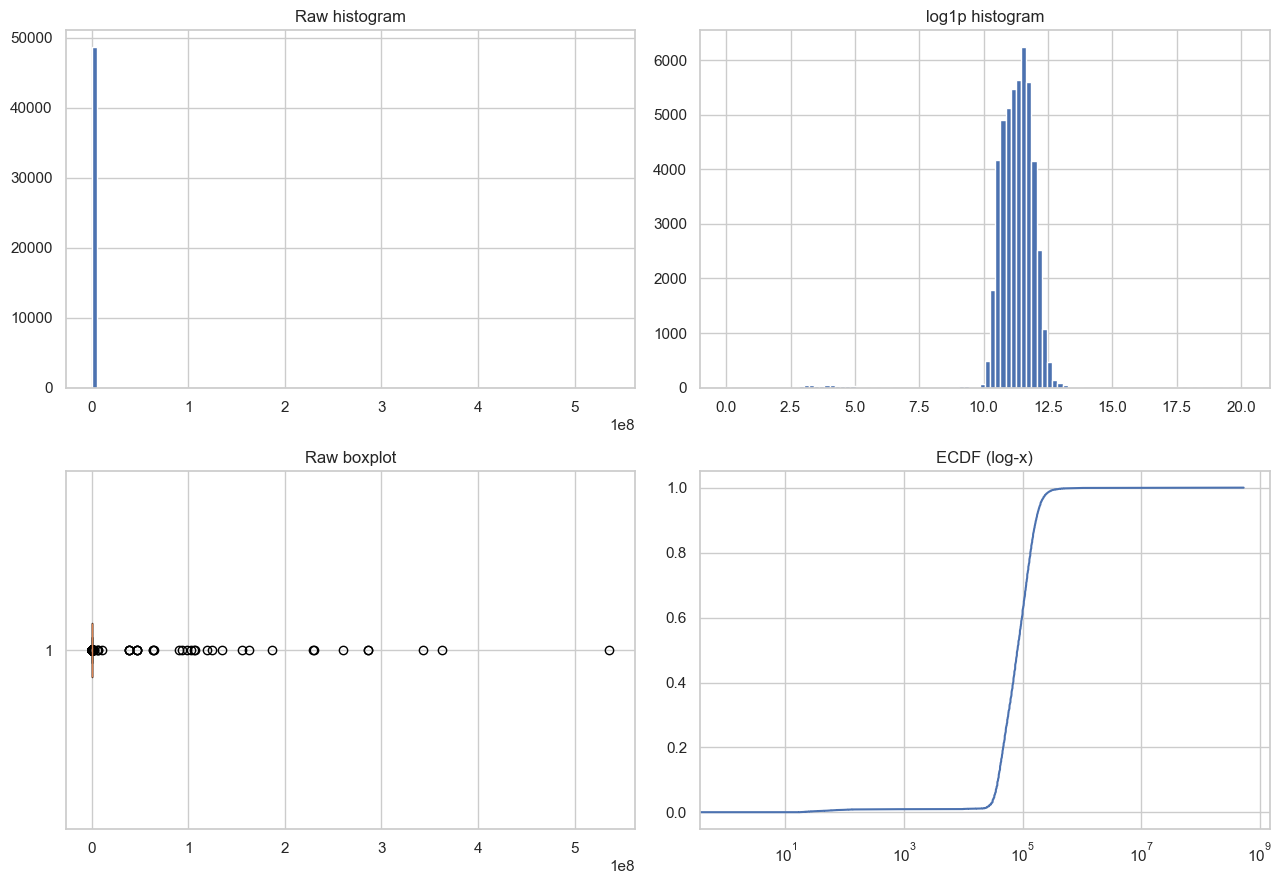

Skewness raw: 69.08 -> log1p: -4.55
Kurtosis raw: 5724.81 -> log1p: 40.55


In [29]:
log_target = np.log1p(target)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes[0,0].hist(target, bins=100); axes[0,0].set_title("Raw histogram")
axes[0,1].hist(log_target, bins=100); axes[0,1].set_title("log1p histogram")
axes[1,0].boxplot(target, vert=False); axes[1,0].set_title("Raw boxplot")
sorted_t = np.sort(target)
ecdf = np.arange(1, len(sorted_t)+1) / len(sorted_t)
axes[1,1].plot(sorted_t, ecdf); axes[1,1].set_xscale("log"); axes[1,1].set_title("ECDF (log-x)")
plt.tight_layout(); plt.show()

print(f"Skewness raw: {stats.skew(target):.2f} -> log1p: {stats.skew(log_target):.2f}")
print(f"Kurtosis raw: {stats.kurtosis(target):.2f} -> log1p: {stats.kurtosis(log_target):.2f}")


In [30]:
cols_to_show = ["title", "formatted_experience_level", "location", "pay_period",
                "min_salary", "med_salary", "max_salary", "candidate_annual_salary", "currency"]
cols_to_show = [c for c in cols_to_show if c in eda.columns]

lowest_20 = eda.loc[eda["candidate_annual_salary"] > 0].nsmallest(20, "candidate_annual_salary")[cols_to_show]
highest_20 = eda.nlargest(20, "candidate_annual_salary")[cols_to_show]

print("20 LOWEST positive salaries:")
display(lowest_20)
print("20 HIGHEST salaries:")
display(highest_20)


20 LOWEST positive salaries:


,title,formatted_experience_level,location,pay_period,min_salary,med_salary,max_salary,candidate_annual_salary,currency
58907,ACCOUNT DIRECTOR SENIOR-ENTERPRISE 1,director,"Forest Home, NY",yearly,1.00,NaN,1.00,1.000,usd
43210,Regional Sales Manager,associate,"Waukegan, IL",yearly,1.00,NaN,2.00,1.500,usd
102272,Resident Manager,unknown,Kansas City Metropolitan Area,yearly,12.00,NaN,14.00,13.000,usd
26302,Fashion Showroom Intern,unknown,"Los Angeles, CA",yearly,12.00,NaN,15.00,13.500,usd
64393,Assistant Store Manager,mid-senior level,"Fredericksburg, VA",yearly,14.50,NaN,15.25,14.875,usd
26012,Host 238752,mid-senior level,"Ann Arbor, MI",yearly,15.00,NaN,15.00,15.000,usd
81317,Visitor Services Assistant Intern,internship,"Ann Arbor, MI",yearly,15.00,NaN,15.00,15.000,usd
12079,Recreation Aid (Facility Aid) NF-01,entry level,"Fort Riley, KS",yearly,15.00,NaN,16.79,15.895,usd
37504,Recreation Aid NF-01,entry level,"Fort Riley, KS",yearly,15.00,NaN,16.79,15.895,usd
32132,Customer Service Representative,entry level,"Reno, NV",yearly,16.00,NaN,16.00,16.000,usd


20 HIGHEST salaries:


,title,formatted_experience_level,location,pay_period,min_salary,med_salary,max_salary,candidate_annual_salary,currency
41512,Intellectual Property Associate (246215),entry level,"Dallas, TX",hourly,240000.0,NaN,275000.0,535600000.0,usd
129962,"Case Manager RN, Pedi Rheumatology",mid-senior level,"Roseville, CA",hourly,151900.0,NaN,196570.0,362408800.0,usd
24337,Director of Business Development,director,"Palo Alto, CA",hourly,150000.0,NaN,180000.0,343200000.0,usd
45835,Cloud Domain Architect,mid-senior level,"Houston, TX",hourly,125000.0,NaN,150000.0,286000000.0,usd
120254,Cloud Domain Architect,mid-senior level,"Houston, TX",hourly,125000.0,NaN,150000.0,286000000.0,usd
91548,Billing Supervisor (246521),mid-senior level,"Westwood, CA",hourly,125000.0,NaN,125000.0,260000000.0,usd
133498,Manager - Clinical Applications Support - Anci...,unknown,"Lakeland, FL",hourly,98467.0,NaN,123094.0,230423440.0,usd
103148,Sharepoint Developer,unknown,"Springfield, Illinois Metropolitan Area",hourly,100000.0,NaN,120000.0,228800000.0,usd
103875,Trial Paralegal - Hybrid in OC or LA!,mid-senior level,"Los Angeles County, CA",hourly,80000.0,NaN,100000.0,187200000.0,usd
14554,Safety Director,director,"Denver, CO",hourly,73069.0,NaN,84029.0,163381920.0,usd


**Interpretation:** Manually classify the lowest/highest 20 rows above:
- Very low values (e.g. under a few thousand annualized) are almost always
  **unit errors** — a stipend, a bonus, or an hourly figure mislabeled yearly.
- Extreme highs (millions+) are typically **hourly figures entered without
  conversion** or executive compensation packages including equity, not base
  salary — both distort a base-salary regression target.

**Outlier strategy comparison:**

| Strategy | Pro | Con |
|---|---|---|
| A. Hard bounds (e.g. $10k–$1M) | Removes obvious garbage, interpretable | Arbitrary threshold |
| B. Percentile trimming | Data-driven | Can cut legitimate exec/intern pay |
| C. Winsorization | Keeps row count, caps influence | Distorts true tail shape |
| D. log1p target | Reduces skew impact on loss, no rows dropped | Doesn't fix genuine data errors |
| E. Tree models without clipping | Robust to outliers by design | Garbage rows still pollute training if not filtered |

**Decision:** Combine **A + D**: apply a defensible hard sanity floor/ceiling
(e.g. $10,000–$1,000,000 annualized — outside this range is overwhelmingly
data error, not real compensation) to drop clear garbage, then train on
`log1p(candidate_annual_salary)` to tame the remaining right-skew. Avoid
aggressive percentile trimming (B) since it would silently remove legitimate
executive salaries that the business genuinely cares about predicting.

## Section 9 — Salary Disclosure Bias

In [31]:
eda["has_salary_target"] = eda["candidate_annual_salary"].notna()

BIAS_COLS = ["dataset_version", "formatted_experience_level", "formatted_work_type",
             "work_type", "remote_allowed", "company_size", "company_country",
             "company_state", "company_city", "top_industry", "top_skill"]

for c in BIAS_COLS:
    if c not in eda.columns:
        continue
    grp = eda.groupby(eda[c].astype(str), dropna=False)["has_salary_target"]
    tab = grp.agg(total_postings="size", salary_present="sum")
    tab["salary_missing"] = tab["total_postings"] - tab["salary_present"]
    tab["disclosure_rate_pct"] = (tab["salary_present"] / tab["total_postings"] * 100).round(2)
    tab = tab.sort_values("total_postings", ascending=False).head(15)
    print(f"\n=== Disclosure rate by {c} (top 15 by volume) ===")
    display(tab)



=== Disclosure rate by dataset_version (top 15 by volume) ===


,total_postings,salary_present,salary_missing,disclosure_rate_pct
dataset_version,,,,
Version_13,122131,35550,86581,29.11
Version_9,32545,13115,19430,40.30



=== Disclosure rate by formatted_experience_level (top 15 by volume) ===


,total_postings,salary_present,salary_missing,disclosure_rate_pct
formatted_experience_level,,,,
mid-senior level,52577,17477,35100,33.24
entry level,44640,12093,32547,27.09
unknown,36536,11075,25461,30.31
associate,12506,5184,7322,41.45
director,5074,1832,3242,36.11
internship,1836,499,1337,27.18
executive,1507,505,1002,33.51



=== Disclosure rate by formatted_work_type (top 15 by volume) ===


...

,total_postings,salary_present,salary_missing,disclosure_rate_pct
company_city,,,,
new york,8885,3888,4997,43.76
0,4690,1207,3483,25.74
chicago,3773,1305,2468,34.59
atlanta,3409,1334,2075,39.13
san francisco,2606,1050,1556,40.29
houston,2318,468,1850,20.19
dallas,2120,533,1587,25.14
london,2105,948,1157,45.04
san diego,1974,720,1254,36.47



=== Disclosure rate by top_industry (top 15 by volume) ===


,total_postings,salary_present,salary_missing,disclosure_rate_pct
top_industry,,,,
hospitals and health care,20451,4984,15467,24.37
it services and it consulting,11272,2794,8478,24.79
staffing and recruiting,10349,4026,6323,38.90
retail,10056,2064,7992,20.53
financial services,7222,2241,4981,31.03
software development,4162,1579,2583,37.94
construction,3493,1111,2382,31.81
banking,3239,1328,1911,41.00
manufacturing,2669,875,1794,32.78



=== Disclosure rate by top_skill (top 15 by volume) ===


,total_postings,salary_present,salary_missing,disclosure_rate_pct
top_skill,,,,
management,24270,6870,17400,28.31
health care provider,19676,4760,14916,24.19
business development,15919,4537,11382,28.50
information technology,15213,4656,10557,30.61
engineering,14520,4612,9908,31.76
other,12640,3714,8926,29.38
accounting/auditing,6527,3155,3372,48.34
administrative,5599,2341,3258,41.81
marketing,5255,1835,3420,34.92


**Interpretation:** Look for large swings in `disclosure_rate_pct` across
groups — e.g. certain `company_state`s disclosing salary far more often
(consistent with pay-transparency laws in states like CO, NY, CA, WA), or
certain `formatted_experience_level`/`top_industry` groups disclosing less.
This is reported as an observed pattern only — **no causal claim** is made.

**Why it matters for generalization:** if disclosure is non-random, the
~48k-row training set is not a random sample of all 154,676 postings — it's
biased toward whichever states/industries/experience levels disclose more.
A model trained on it may underperform when applied to postings from
low-disclosure segments, since those segments are underrepresented in
training. This should be flagged as a stated limitation in the final report
(Section 36) rather than corrected via reweighting in this notebook.

## Section 10 — Target Relationship with Experience

In [32]:
exp_stats = eda[eda["has_salary_target"]].groupby("formatted_experience_level")["candidate_annual_salary"].agg(
    count="count", median="median", mean="mean",
    p25=lambda s: s.quantile(.25), p75=lambda s: s.quantile(.75), std="std",
).sort_values("median")
display(exp_stats)


C:\Users\lenovo\AppData\Local\Temp\ipykernel_3936\3792223925.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  exp_stats = eda[eda["has_salary_target"]].groupby("formatted_experience_level")["candidate_annual_salary"].agg(


,count,median,mean,p25,p75,std
formatted_experience_level,,,,,,
internship,499,48900.8,744413.847665,41340.00,62450.0,5.417353e+06
entry level,12093,52000.0,210878.547470,40560.00,76960.0,5.898477e+06
associate,5184,72800.0,82321.419565,55000.00,98800.0,4.757203e+04
unknown,11075,77500.0,145647.920871,51213.24,120000.0,3.236562e+06
mid-senior level,17477,107500.0,192491.809834,75000.00,140000.0,4.768063e+06
director,1832,166400.0,446993.750308,130000.00,201182.0,8.873650e+06
executive,505,187500.0,197615.992970,127500.00,250000.0,1.039602e+05


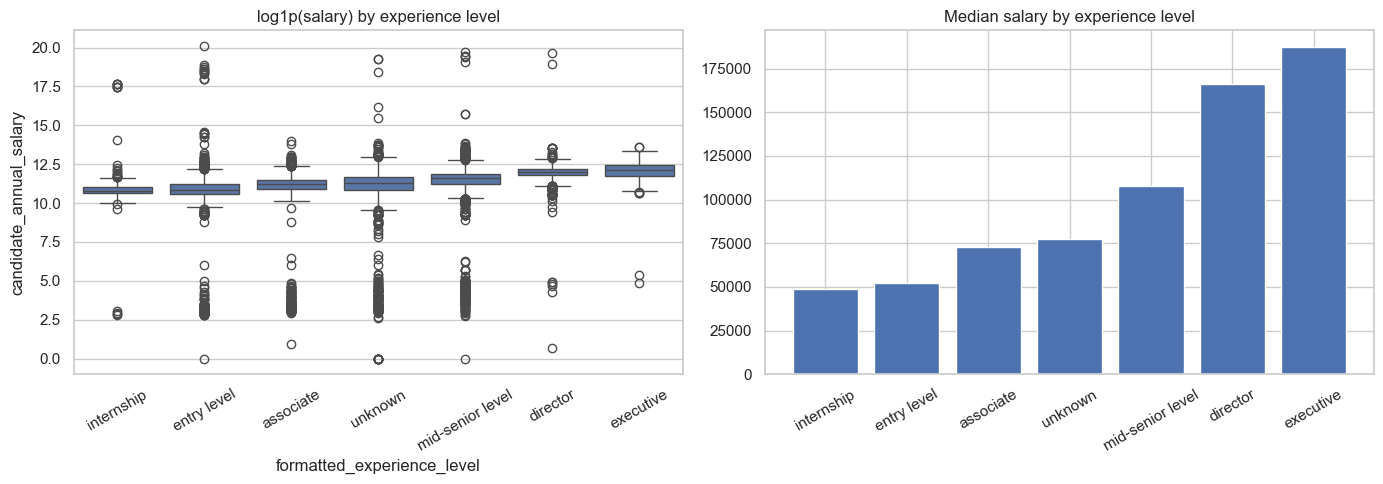

Median salary rank by level (compare to expected monotonic order):


formatted_experience_level
internship           48900.8
entry level          52000.0
associate            72800.0
unknown              77500.0
mid-senior level    107500.0
director            166400.0
executive           187500.0
Name: median, dtype: float64

In [33]:
order = exp_stats.index.tolist()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=eda[eda["has_salary_target"]], x="formatted_experience_level",
            y=np.log1p(eda.loc[eda["has_salary_target"], "candidate_annual_salary"]),
            order=order, ax=axes[0])
axes[0].set_title("log1p(salary) by experience level"); axes[0].tick_params(axis='x', rotation=30)
axes[1].bar(exp_stats.index.astype(str), exp_stats["median"])
axes[1].set_title("Median salary by experience level"); axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

EXPECTED_ORDER = ["internship", "entry level", "associate", "mid-senior level", "director", "executive"]
observed_rank = exp_stats["median"].rank()
print("Median salary rank by level (compare to expected monotonic order):")
display(exp_stats["median"])


**Interpretation:** Check whether median salary increases monotonically
through internship → entry level → associate → mid-senior level → director →
executive. If it does (even approximately), the ordinal mapping is empirically
supported. If any level is out of order (e.g. "associate" paying less than
"entry level" in this data), note the deviation explicitly rather than forcing
the assumed order.

**Decision:** Use the ordinal mapping only where the evidence above confirms
monotonicity; where it clearly doesn't hold, prefer one-hot/frequency encoding
over ordinal for `formatted_experience_level` in the final pipeline.

## Section 11 — Target Relationship with Work Type

In [34]:
for c in ["formatted_work_type", "work_type"]:
    if c not in eda.columns:
        continue
    tab = eda[eda["has_salary_target"]].groupby(c)["candidate_annual_salary"].agg(
        count="count", median="median", mean="mean", std="std")
    print(f"\n=== {c} ===")
    display(tab.sort_values("median", ascending=False))

if "formatted_work_type" in eda.columns and "work_type" in eda.columns:
    overlap = pd.crosstab(eda["formatted_work_type"], eda["work_type"])
    print("\nCrosstab formatted_work_type x work_type:")
    display(overlap)
    identical_share = (eda["formatted_work_type"].astype(str).str.lower().str.replace("_"," ") ==
                        eda["work_type"].astype(str).str.lower().str.replace("_"," ")).mean()
    print(f"Share of rows where the two columns represent the same category: {identical_share*100:.1f}%")



=== formatted_work_type ===


C:\Users\lenovo\AppData\Local\Temp\ipykernel_3936\1957669217.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = eda[eda["has_salary_target"]].groupby(c)["candidate_annual_salary"].agg(


,count,median,mean,std
formatted_work_type,,,,
contract,5094,94640.0,1.018319e+05,1.313450e+05
full-time,39732,84910.8,2.033523e+05,5.199180e+06
other,173,62000.0,7.914925e+04,6.020941e+04
temporary,506,54862.4,7.072796e+04,4.725975e+04
internship,306,45760.0,1.173899e+06,6.887339e+06
part-time,2846,41600.0,8.331984e+04,1.223074e+06
volunteer,8,0.0,1.754562e+04,2.439714e+04



=== work_type ===


C:\Users\lenovo\AppData\Local\Temp\ipykernel_3936\1957669217.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = eda[eda["has_salary_target"]].groupby(c)["candidate_annual_salary"].agg(


,count,median,mean,std
work_type,,,,
contract,5094,94640.0,1.018319e+05,1.313450e+05
full_time,39732,84910.8,2.033523e+05,5.199180e+06
other,173,62000.0,7.914925e+04,6.020941e+04
temporary,506,54862.4,7.072796e+04,4.725975e+04
internship,306,45760.0,1.173899e+06,6.887339e+06
part_time,2846,41600.0,8.331984e+04,1.223074e+06
volunteer,8,0.0,1.754562e+04,2.439714e+04



Crosstab formatted_work_type x work_type:


work_type,contract,full_time,internship,other,part_time,temporary,volunteer
formatted_work_type,,,,,,,
contract,15359,0,0,0,0,0,0
full-time,0,123898,0,0,0,0,0
internship,0,0,1182,0,0,0,0
other,0,0,0,546,0,0,0
part-time,0,0,0,0,11662,0,0
temporary,0,0,0,0,0,1430,0
volunteer,0,0,0,0,0,0,599


Share of rows where the two columns represent the same category: 12.4%


**Interpretation:** The crosstab shows whether `formatted_work_type` and
`work_type` are effectively the same field under different formatting
(e.g. "full-time" vs "full_time") or carry genuinely different information.

**Decision:** If they're near-duplicates (diagonal-dominant crosstab), keep
only one — prefer `formatted_work_type` since it's the human-readable, display
version consistent with `formatted_experience_level`. Using both would add
redundant, perfectly-correlated dummy columns.

## Section 12 — Remote Work Relationship

In [35]:
if "remote_allowed" in eda.columns:
    remote_stats = eda[eda["has_salary_target"]].groupby("remote_allowed")["candidate_annual_salary"].agg(
        count="count", mean="mean", median="median",
        p25=lambda s: s.quantile(.25), p75=lambda s: s.quantile(.75))
    display(remote_stats)

    # Partial control: within experience level and state
    grouped = eda[eda["has_salary_target"]].groupby(
        ["remote_allowed", "formatted_experience_level"])["candidate_annual_salary"].median().unstack(0)
    display(grouped)
else:
    print("remote_allowed present but check Section 7 data-quality note — "
          "the data dictionary flags this column as constant (100% True). "
          "If confirmed constant here, it carries zero predictive information "
          "regardless of any salary relationship shown above.")


,count,mean,median,p25,p75
remote_allowed,,,,,
True,48665,189957.664332,82150.0,52000.0,125000.0


C:\Users\lenovo\AppData\Local\Temp\ipykernel_3936\2256228751.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = eda[eda["has_salary_target"]].groupby(


remote_allowed,True
formatted_experience_level,
associate,72800.0
director,166400.0
entry level,52000.0
executive,187500.0
internship,48900.8
mid-senior level,107500.0
unknown,77500.0


**Interpretation:** Per the data dictionary, `remote_allowed` was flagged
as constant (100% True) in the source feature store — if that holds here too,
any apparent salary relationship is meaningless (no variance to learn from)
and the column should not be treated as informative even if a naive groupby
shows a difference (there wouldn't be one to show).

**Decision:** Re-verify constancy in this actual data; if confirmed constant,
mark `remote_allowed` `DROP_LOW_VALUE` in the Section 23 leakage/value audit.

## Section 13 — Geographical Salary Relationships

In [36]:
GEO_COLS = ["location", "company_country", "company_state", "company_city", "zip_code", "fips"]
for c in GEO_COLS:
    if c in eda.columns:
        print(f"{c}: {eda[c].nunique():,} unique values, {eda[c].isna().mean()*100:.2f}% missing")


location: 9,229 unique values, 0.00% missing
company_country: 86 unique values, 0.00% missing
company_state: 690 unique values, 0.00% missing
company_city: 4,260 unique values, 0.00% missing
zip_code: 6,938 unique values, 34.15% missing
fips: 2,260 unique values, 38.33% missing


In [37]:
def geo_salary_table(col, min_support=MIN_SUPPORT, top=15):
    g = eda[eda['has_salary_target']].groupby(col)['candidate_annual_salary']
    tab = g.agg(count='count', median='median', mean='mean',
                p25=lambda s: s.quantile(.25), p75=lambda s: s.quantile(.75))
    tab['iqr'] = tab['p75'] - tab['p25']
    tab = tab[tab['count'] >= min_support]
    return tab

for level in ["company_country", "company_state", "company_city"]:
    if level not in eda.columns:
        continue
    tab = geo_salary_table(level)
    print(f"\n=== {level}: {len(tab)} groups with >= {MIN_SUPPORT} salary observations ===")
    print("Highest median:")
    display(tab.sort_values('median', ascending=False).head(10))
    print("Lowest median:")
    display(tab.sort_values('median').head(10))
    print("Highest support:")
    display(tab.sort_values('count', ascending=False).head(10))



=== company_country: 17 groups with >= 30 salary observations ===
Highest median:


C:\Users\lenovo\AppData\Local\Temp\ipykernel_3936\1643236410.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = eda[eda['has_salary_target']].groupby(col)['candidate_annual_salary']


,count,median,mean,p25,p75,iqr
company_country,,,,,,
oo,48,127000.0,135265.937500,99500.000,178940.0,79440.000
no,56,121250.0,117431.007143,97250.000,137500.0,40250.000
ie,65,115000.0,110594.713923,77249.000,135000.0,57751.000
gb,1531,112500.0,128231.180078,75710.000,156000.0,80290.000
cn,30,108750.0,121709.250000,73281.875,166212.5,92930.625
fr,160,100000.0,104431.605781,64495.000,138875.0,74380.000
jp,52,99750.0,111817.753846,76500.000,152375.0,75875.000
in,136,96720.0,91103.174265,60096.400,125210.0,65113.600
0,905,93600.0,103184.821663,58000.000,135200.0,77200.000


Lowest median:


,count,median,mean,p25,p75,iqr
company_country,,,,,,
dk,53,55120.0,84932.569811,45760.0,89750.0,43990.0
ca,445,62400.0,83180.430112,45593.6,109150.0,63556.4
se,116,64480.0,69988.928448,41186.6,92500.0,51313.4
ch,208,73300.0,83055.243750,45600.0,107575.0,61975.0
us,44297,80000.0,197996.777101,51386.4,123000.0,71613.6
nl,108,84450.0,103175.205602,47842.6,122222.0,74379.4
de,186,86500.0,107119.059677,46592.0,128845.0,82253.0
au,61,92500.0,107476.788525,62400.0,132500.0,70100.0
0,905,93600.0,103184.821663,58000.0,135200.0,77200.0


...

,count,median,mean,p25,p75,iqr
company_city,,,,,,
the cloud,33,207550.0,215313.636364,175850.0,269750.00,93900.00
mountain view,261,173500.0,177791.613410,140500.0,210000.00,69500.00
rahway,40,166250.0,181300.900000,130100.0,233700.00,103600.00
sunnyvale,51,165000.0,166631.647059,123750.0,196606.25,72856.25
foster city,109,163200.0,175729.032110,137775.0,213232.50,75457.50
south san francisco,45,150500.0,151728.311111,101484.0,187500.00,86016.00
venice,44,149825.0,144548.863636,106400.0,181037.50,74637.50
redmond,62,148550.0,149800.451613,116737.5,190580.00,73842.50
san mateo,51,147500.0,171012.431373,99250.0,216500.00,117250.00


Lowest median:


,count,median,mean,p25,p75,iqr
company_city,,,,,,
knoxville,78,33675.2,46648.953846,29185.0,43680.0,14495.0
marlborough,81,33800.0,44677.244444,31720.0,38480.0,6760.0
greater chicago area,41,35360.0,38521.170732,31200.0,39520.0,8320.0
laval,35,35880.0,41156.754286,33280.0,42359.2,9079.2
calabasas,88,36171.2,42364.493182,32916.0,39624.0,6708.0
fairview park,65,36400.0,41435.187692,31200.0,41600.0,10400.0
deerfield beach,36,36660.0,45440.111111,34320.0,41210.0,6890.0
mooresville,53,37128.0,55110.792453,35048.0,48568.0,13520.0
woodland hills,34,37648.0,48181.694118,37648.0,43534.4,5886.4


Highest support:


,count,median,mean,p25,p75,iqr
company_city,,,,,,
new york,3888,95000.0,1.353655e+05,62400.0,137500.000,75100.000
atlanta,1334,80000.0,8.700238e+04,50523.2,115000.000,64476.800
chicago,1305,71000.0,8.748098e+04,50000.0,109424.195,59424.195
0,1207,82500.0,9.651683e+04,52000.0,127500.000,75500.000
san francisco,1050,124170.0,1.310396e+05,73497.6,175775.000,102277.400
london,948,120000.0,1.342522e+05,80562.5,160000.000,79437.500
los angeles,887,93600.0,1.106640e+05,62964.6,144255.500,81290.900
san diego,720,93050.0,1.211088e+06,60320.0,132196.400,71876.400
boston,713,90000.0,1.002789e+05,64000.0,125000.000,61000.000


**Interpretation:** `company_state` is the right granularity for V1 — it
has enough per-group support (Section 4 of the data dictionary lists it as
moderate cardinality, ~690 raw values but state-level should collapse this a
lot) to compute stable statistics, unlike `company_city` (4,260 raw values,
mostly below the 30-observation support threshold) or `zip_code`/`fips`
(sparse and too granular). `location` is a raw free-text field that likely
duplicates city/state information already captured more cleanly in
`company_state`/`company_country`.

**Decision:** Use `company_state` (frequency or target-encoded on TRAIN ONLY)
as the primary geography feature for V1; keep `company_country` as a coarse
backup for non-US rows; drop raw `location`, `zip_code`, `fips`, and
`company_city` from V1 due to sparsity/redundancy — revisit `company_city`
for V2 if state alone underperforms.

## Section 14 — Company Characteristics vs Salary

In [38]:
num_company_cols = [c for c in ["company_employee_count", "company_follower_count"] if c in eda.columns]
sub = eda[eda["has_salary_target"]].copy()

for c in num_company_cols:
    sub[f"log_{c}"] = np.log1p(sub[c].clip(lower=0))

corr_rows = []
for c in num_company_cols:
    pear = sub[c].corr(sub["candidate_annual_salary"])
    spear = sub[c].corr(sub["candidate_annual_salary"], method="spearman")
    pear_log = sub[f"log_{c}"].corr(np.log1p(sub["candidate_annual_salary"]))
    corr_rows.append({"feature": c, "pearson_raw": pear, "spearman_raw": spear, "pearson_log_log": pear_log})
display(pd.DataFrame(corr_rows))


,feature,pearson_raw,spearman_raw,pearson_log_log
0,company_employee_count,0.002270,-0.031187,0.014570
1,company_follower_count,0.000394,0.155574,0.109295


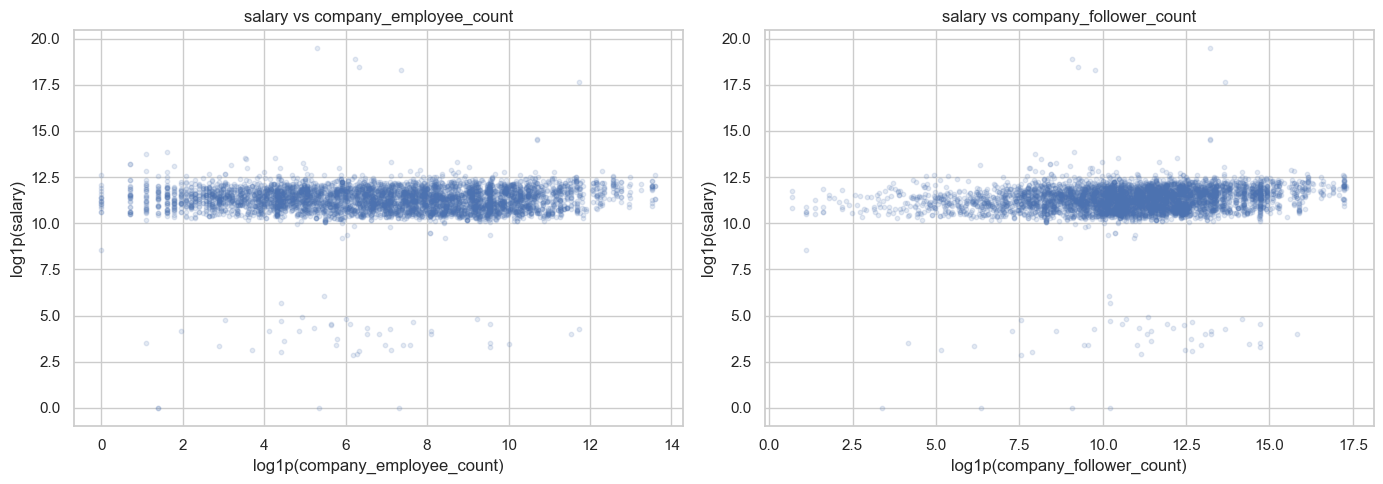

C:\Users\lenovo\AppData\Local\Temp\ipykernel_3936\260926353.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_stats = sub.groupby("company_size")["candidate_annual_salary"].agg(


,count,median,mean
company_size,,,
1.0,4281,85105.0,99520.433706
2.0,6088,88400.0,168122.066767
3.0,4121,90000.0,485325.263582
4.0,3787,83125.0,303373.125594
5.0,9199,82500.0,154960.358928
6.0,4041,75000.0,171956.958638
7.0,14719,74440.0,140375.773577
unknown,2429,90000.0,189076.473759


In [39]:
fig, axes = plt.subplots(1, len(num_company_cols), figsize=(7*len(num_company_cols), 5))
if len(num_company_cols) == 1:
    axes = [axes]
for ax, c in zip(axes, num_company_cols):
    sample = sub.sample(min(5000, len(sub)), random_state=RANDOM_STATE)
    ax.scatter(np.log1p(sample[c]), np.log1p(sample["candidate_annual_salary"]), alpha=0.15, s=10)
    ax.set_xlabel(f"log1p({c})"); ax.set_ylabel("log1p(salary)")
    ax.set_title(f"salary vs {c}")
plt.tight_layout(); plt.show()

if "company_size" in eda.columns:
    size_stats = sub.groupby("company_size")["candidate_annual_salary"].agg(
        count="count", median="median", mean="mean")
    display(size_stats)


**Interpretation:** `company_employee_count` and `company_follower_count`
are both extremely right-skewed (per Section 6 of the data dictionary, means
far exceed medians), so raw correlations will understate their relationship —
log-log correlation is the more honest read. `company_size` (the ordinal
1.0–7.0 bucket) should show whether size itself, independent of raw counts,
tracks salary in a step-wise way.

**Decision:** Include `log1p(company_employee_count)` and
`log1p(company_follower_count)` as continuous features, plus
`company_size_ordinal` — check for redundancy between the three at modeling
time via the Section 27 correlation heatmap rather than assuming it here.

## Section 15 — Industry Relationship

In [40]:
for c in ["top_industry", "industry_list", "industry_count"]:
    if c in eda.columns:
        print(f"{c}: cardinality={eda[c].nunique():,}, missing={eda[c].isna().mean()*100:.2f}%")

ind_tab = geo_salary_table("top_industry", min_support=MIN_SUPPORT)
print(f"\nIndustries with >= {MIN_SUPPORT} salary observations: {len(ind_tab)}")
print("Top 20 by observation count:")
display(ind_tab.sort_values("count", ascending=False).head(20))
print("Top 20 by median salary (support-filtered):")
display(ind_tab.sort_values("median", ascending=False).head(20))


top_industry: cardinality=380, missing=0.09%
industry_list: cardinality=5,360, missing=0.09%
industry_count: cardinality=4, missing=0.00%

Industries with >= 30 salary observations: 125
Top 20 by observation count:


,count,median,mean,p25,p75,iqr
top_industry,,,,,,
hospitals and health care,4984,81515.2000,281926.455887,50070.800,118123.2000,68052.4000
staffing and recruiting,4026,85000.0000,463942.903615,53040.000,121680.0000,68640.0000
it services and it consulting,2794,110240.0000,202907.578887,71697.600,145600.0000,73902.4000
financial services,2241,105200.0000,116509.062932,68319.840,150000.0000,81680.1600
retail,2064,40352.0000,52366.720552,33800.000,57200.0000,23400.0000
software development,1579,130500.0000,199079.623312,85000.000,170000.0000,85000.0000
banking,1328,91760.0000,103283.777895,56157.950,135625.0000,79467.0500
accounting,1137,90000.0000,97832.910765,64000.000,125000.0000,61000.0000
construction,1111,90000.0000,95983.835104,64490.000,124364.3325,59874.3325


Top 20 by median salary (support-filtered):


,count,median,mean,p25,p75,iqr
top_industry,,,,,,
capital markets,79,175000.0,271207.088608,132500.000,337500.000,205000.000
information services,436,145000.0,146916.487156,105000.000,183000.000,78000.000
venture capital and private equity principals,46,144000.0,138556.086957,105500.000,150000.000,44500.000
semiconductor manufacturing,133,137177.0,130409.665451,85000.000,163500.000,78500.000
computer hardware manufacturing,271,137000.0,596062.707380,75650.000,184690.000,109040.000
computer and network security,269,134080.0,141958.274833,100000.000,174410.000,74410.000
software development,1579,130500.0,199079.623312,85000.000,170000.000,85000.000
"technology, information and internet",482,130000.0,135472.345685,80125.000,180075.000,99950.000
defense and space manufacturing,368,125000.0,128098.383832,91020.375,159000.000,67979.625


In [41]:
# Redundancy check: does industry_count add info beyond top_industry, and does
# industry_list mostly just repeat top_industry as a single-item list?
if "industry_list" in eda.columns and "top_industry" in eda.columns:
    sample_compare = eda[["top_industry", "industry_list", "industry_count"]].dropna().sample(
        min(10, eda["top_industry"].notna().sum()), random_state=RANDOM_STATE)
    display(sample_compare)


,top_industry,industry_list,industry_count
7499,retail,RETAIL,1
65202,law practice,LAW_PRACTICE,1
73982,law practice,LAW_PRACTICE,1
39847,hospitals and health care,HOSPITALS_AND_HEALTH_CARE,1
13607,wellness and fitness services,WELLNESS_AND_FITNESS_SERVICES,1
73235,information technology & services,INFORMATION_TECHNOLOGY_SERVICES,1
136050,biotechnology research,BIOTECHNOLOGY_RESEARCH|IT_SERVICES_AND_IT_CONS...,3
138158,"technology, information and internet",TECHNOLOGY_INFORMATION_AND_INTERNET,1
64189,it services and it consulting,IT_SERVICES_AND_IT_CONSULTING|TECHNOLOGY_INFOR...,3
95884,construction,CONSTRUCTION,1


**Interpretation:** `top_industry` gives a clean single-label signal with
manageable cardinality once filtered to industries with sufficient support.
Check the sample comparison above — if `industry_list` is usually a 1-item
list identical to `top_industry` (consistent with mean `industry_count` ≈ 1.3
per the data dictionary), it's largely redundant for most rows and only adds
value for the minority of multi-industry postings.

**Decision:** Use `top_industry` (frequency-encoded, train-only) as the
primary industry feature for V1. Treat `industry_list`/`industry_count` as
`DROP_REDUNDANT` for V1, revisit as a multi-label feature for V2/V3 only if
`top_industry` alone underperforms.

## Section 16 — Skills vs Salary

In [42]:
print("skill_list dtype/sample:", eda["skill_list"].dtype)
print(eda["skill_list"].dropna().iloc[0])
print(type(eda["skill_list"].dropna().iloc[0]))


skill_list dtype/sample: object
OTHER
<class 'str'>


In [43]:
def to_skill_list(v):
    if isinstance(v, (list, np.ndarray)):
        return list(v)
    if isinstance(v, str):
        return [s.strip() for s in v.split("|") if s.strip()]
    return []

eda["skill_list_parsed"] = eda["skill_list"].apply(to_skill_list)
skill_coverage = (eda["skill_list_parsed"].str.len() > 0).mean()
print(f"Skill coverage: {skill_coverage*100:.1f}% of rows have >=1 parsed skill")
display(eda["skill_count"].describe())

exploded = eda[["skill_list_parsed", "candidate_annual_salary"]].explode("skill_list_parsed")
exploded = exploded.rename(columns={"skill_list_parsed": "skill"})
top50_by_freq = exploded["skill"].value_counts().head(50)
display(top50_by_freq)


Skill coverage: 98.3% of rows have >=1 parsed skill


count    154676.000000
mean          1.667531
std           0.709226
min           0.000000
25%           1.000000
50%           2.000000
75%           2.000000
max           3.000000
Name: skill_count, dtype: float64

skill
INFORMATION_TECHNOLOGY    32225
SALES                     26208
MANAGEMENT                25107
MANUFACTURING             22031
HEALTH_CARE_PROVIDER      20257
BUSINESS_DEVELOPMENT      16572
ENGINEERING               16148
OTHER                     15244
FINANCE                   10322
MARKETING                  6864
ACCOUNTING_AUDITING        6527
ADMINISTRATIVE             5897
PROJECT_MANAGEMENT         4999
CUSTOMER_SERVICE           4972
ANALYST                    4696
RESEARCH                   3687
HUMAN_RESOURCES            3325
DESIGN                     2863
LEGAL                      2807
CONSULTING                 2755
EDUCATION                  2696
TRAINING                   2559
GENERAL_BUSINESS           2371
QUALITY_ASSURANCE          2236
ART_CREATIVE               2132
WRITING_EDITING            1852
PUBLIC_RELATIONS           1681
PRODUCT_MANAGEMENT         1643
STRATEGY_PLANNING          1505
SUPPLY_CHAIN               1505
ADVERTISING                 991
SC

In [44]:
skill_salary = exploded.dropna(subset=["candidate_annual_salary"]).groupby("skill")["candidate_annual_salary"].agg(
    count="count", median="median", mean="mean")
skill_salary_supported = skill_salary[skill_salary["count"] >= MIN_SUPPORT]
print(f"Skills with >= {MIN_SUPPORT} salary observations: {len(skill_salary_supported)}")
display(skill_salary_supported.sort_values("count", ascending=False).head(20))
display(skill_salary_supported.sort_values("median", ascending=False).head(20))


Skills with >= 30 salary observations: 35


,count,median,mean
skill,,,
INFORMATION_TECHNOLOGY,9852,112320.00,246863.224378
SALES,7670,75323.00,184904.076731
MANAGEMENT,7349,59280.00,106736.073123
MANUFACTURING,6334,55080.65,104077.651216
ENGINEERING,5258,120000.00,262847.367064
HEALTH_CARE_PROVIDER,4927,86500.00,223235.860990
BUSINESS_DEVELOPMENT,4760,78000.00,194253.658152
OTHER,4687,57500.00,147206.611257
FINANCE,4073,91000.00,217220.890500


,count,median,mean
skill,,,
PRODUCT_MANAGEMENT,653,140500.00,146242.320858
STRATEGY_PLANNING,657,125000.00,132026.081431
ENGINEERING,5258,120000.00,262847.367064
LEGAL,1304,115000.00,691139.905475
CONSULTING,1038,115000.00,129319.552216
PROJECT_MANAGEMENT,1985,114400.00,118879.182685
INFORMATION_TECHNOLOGY,9852,112320.00,246863.224378
ADVERTISING,378,102500.00,116579.378571
ANALYST,1673,93600.00,102164.687026


**Interpretation:** Confirm the storage format first (pipe-delimited
string vs native list/array — the code above handles both). Skill coverage
and per-skill salary spread determine whether skills carry independent salary
signal beyond title/industry.

**Recommendation for representation:** Given cardinality of ~2,302 distinct
skills (per the data dictionary) but a low mean skill_count (~1.67 per
posting), full one-hot encoding is wasteful and sparse. **Top-N skill
indicators** (binary flags for the ~50–100 most frequent, sufficiently-salary-
supported skills) is the most defensible V1/V2 approach — it's interpretable
and avoids the dimensionality blow-up of `MultiLabelBinarizer` over the full
vocabulary. Reserve embeddings for a later, more exploratory V3.

**Decision:** `top_skill` (single most prominent skill, frequency-encoded) for
V1; top-N `skill_list` multi-hot indicators as a V2 addition.

## Section 17 — Job Title Analysis

In [45]:
title_counts = eda["title"].value_counts()
print(f"Unique titles: {eda['title'].nunique():,}")
print(f"Titles appearing exactly once: {(title_counts == 1).sum():,}")
print(f"Titles appearing >= 5 times: {(title_counts >= 5).sum():,}")
print(f"Titles appearing >= 10 times: {(title_counts >= 10).sum():,}")
print(f"Titles appearing >= 50 times: {(title_counts >= 50).sum():,}")


Unique titles: 89,189
Titles appearing exactly once: 75,186
Titles appearing >= 5 times: 3,304
Titles appearing >= 10 times: 1,357
Titles appearing >= 50 times: 165


In [46]:
common_titles = title_counts[title_counts >= 10].index
title_salary = eda[eda["has_salary_target"] & eda["title"].isin(common_titles)].groupby(
    "title")["candidate_annual_salary"].agg(count="count", median="median", mean="mean")

print("Most common titles:")
display(title_counts.head(20))
print("Highest-paying common titles (>=10 postings, >=10 salary obs):")
display(title_salary[title_salary["count"] >= 10].sort_values("median", ascending=False).head(20))


Most common titles:


title
Sales Manager                      765
Customer Service Representative    446
Project Manager                    445
Senior Accountant                  318
Administrative Assistant           311
Executive Assistant                286
Staff Accountant                   276
Retail Sales Associate             273
Sales Associate                    269
Account Executive                  261
Controller                         233
Receptionist                       230
Registered Nurse                   230
Software Engineer                  227
Account Manager                    214
Maintenance Technician             204
Assistant Store Manager            200
Salesperson                        200
Store Manager                      196
Business Development Manager       195
Name: count, dtype: int64

Highest-paying common titles (>=10 postings, >=10 salary obs):


,count,median,mean
title,,,
Labor And Employment Attorney,11,225000.0,232118.181818
Primary Care Physician,12,224250.0,214375.000000
Chief Financial Officer,25,220000.0,231700.000000
Head of Sales,10,218750.0,211900.000000
Sales Director [Owner/Operator],57,201182.0,201182.000000
Chief Operating Officer,11,200000.0,189287.727273
Principal Software Engineer,10,199825.0,186195.000000
Remote Licensed Mental Health Counselor,11,187200.0,188334.545455
Senior Data Scientist,20,181500.0,175925.000000


In [47]:
SENIORITY_KEYWORDS = ["intern", "junior", "jr", "associate", "senior", "sr", "lead",
                       "staff", "principal", "manager", "director", "head", "vp",
                       "vice president", "chief"]

kw_rows = []
title_lower = eda["title"].astype(str).str.lower()
for kw in SENIORITY_KEYWORDS:
    mask = title_lower.str.contains(rf"\b{kw}\b", regex=True)
    sub = eda.loc[mask & eda["has_salary_target"], "candidate_annual_salary"]
    kw_rows.append({"keyword": kw, "occurrence_count": int(mask.sum()),
                     "salary_median": sub.median(), "salary_mean": sub.mean(),
                     "salary_n": len(sub)})
display(pd.DataFrame(kw_rows).sort_values("salary_median", ascending=False))


,keyword,occurrence_count,salary_median,salary_mean,salary_n
11,head,440,200000.00,203722.153846,156
12,vp,377,190000.00,198129.519207,145
13,vice president,721,186636.25,206327.841467,276
14,chief,562,175000.00,188638.308712,198
8,principal,953,170000.00,170323.400403,372
10,director,5669,160000.00,464112.754742,2016
5,sr,3072,130000.00,133593.265298,1058
4,senior,10351,125000.00,132748.716027,3976
6,lead,3989,115000.00,114612.937758,1151
9,manager,23347,107350.00,187714.541003,7841


**Interpretation:** If seniority keywords show a clear salary gradient
(e.g. "chief"/"vp"/"director" >> "senior"/"lead" >> "junior"/"intern"), title
text alone carries strong salary signal beyond the structured
`formatted_experience_level` field, since job titles encode nuance (e.g.
"Staff Engineer" vs "Senior Engineer") that the coarse 6-level experience
field can't.

**Decision:** Raw `title` is NOT one-hot encoded (89,189 unique values would
be unusable). It's carried forward only via derived features: keyword
indicators (Section 17) and, if justified, TF-IDF (Section 18) for V2.

## Section 18 — NLP Feasibility: Title

In [48]:
eda["title_length"] = eda["title"].astype(str).str.len()
eda["title_word_count"] = eda["title"].astype(str).str.split().str.len()
display(eda[["title_length", "title_word_count"]].describe())


,title_length,title_word_count
count,154676.000000,154676.000000
mean,31.519958,4.251733
std,16.226725,2.515431
min,2.000000,1.000000
25%,20.000000,3.000000
50%,28.000000,3.000000
75%,39.000000,5.000000
max,200.000000,31.000000


In [49]:
import re
from collections import Counter

STOPWORDS = {"and", "or", "the", "a", "an", "of", "in", "for", "to", "at", "on", "with"}

def tokenize(s):
    return [w for w in re.findall(r"[a-z]+", s.lower()) if w not in STOPWORDS]

all_tokens = eda["title"].astype(str).apply(tokenize)
word_counter = Counter(w for toks in all_tokens for w in toks)
bigram_counter = Counter(
    tuple(toks[i:i+2]) for toks in all_tokens for i in range(len(toks)-1)
)

print("Most common title words:")
display(pd.Series(dict(word_counter.most_common(25))))
print("Most common title bigrams:")
display(pd.Series({" ".join(k): v for k, v in bigram_counter.most_common(25)}))


Most common title words:


manager           23481
engineer          12869
senior            10378
sales             10251
associate          8454
specialist         8377
assistant          8375
technician         6668
analyst            6457
nurse              6290
time               6140
director           5725
service            4468
project            4225
rn                 4086
lead               4002
representative     3789
business           3615
registered         3615
coordinator        3557
part               3375
full               3296
operations         3251
developer          3232
sr                 3079
dtype: int64

Most common title bigrams:


part time                   3354
registered nurse            3228
full time                   2656
project manager             2580
sales associate             2084
nurse rn                    1837
software engineer           1690
customer service            1685
sales manager               1585
account manager             1371
sales representative        1313
store manager               1286
service representative      1104
account executive           1074
retail sales                1060
business development         996
entry level                  972
program manager              891
human resources              790
nd shift                     786
business analyst             754
administrative assistant     742
practical nurse              732
licensed practical           729
vice president               725
dtype: int64

**Interpretation:** Combined with the seniority-keyword salary gradient
from Section 17, common words/bigrams reveal the structure of the title
vocabulary (role words like "engineer", "manager", "sales" vs seniority
modifiers). This confirms titles are compositional (seniority + function),
which word-level TF-IDF captures naturally.

**Recommendation:** TF-IDF **word n-grams** (uni+bigrams) over title text for
V2 — titles are short and word-boundary-meaningful, so character n-grams add
little beyond handling typos, which are rare in structured job postings.
Embeddings are reserved for V3 description modeling where semantic nuance
matters more than in short titles.

## Section 19 — NLP Feasibility: Description (LEAKAGE CHECK — CRITICAL)

In [50]:
eda["description_missing_pct"] = eda["description"].isna().mean() * 100
eda["desc_char_len"] = eda["description"].astype(str).str.len()
eda["desc_word_count"] = eda["description"].astype(str).str.split().str.len()

print(f"Description missing %: {eda['description'].isna().mean()*100:.2f}%")
display(eda[["desc_char_len", "desc_word_count"]].describe(percentiles=[.5, .95]))


Description missing %: 0.00%


,desc_char_len,desc_word_count
count,154676.000000,154676.000000
mean,3765.015471,525.213220
std,2129.853005,300.977196
min,2.000000,1.000000
50%,3442.000000,480.000000
95%,7658.000000,1074.000000
max,23106.000000,3400.000000


In [51]:
SALARY_PATTERNS = [r"\$", r"salary", r"compensation", r"\bpay\b",
                    r"per hour", r"per year", r"annually"]
pattern = "|".join(SALARY_PATTERNS)

desc_lower = eda["description"].astype(str).str.lower()
has_salary_lang = desc_lower.str.contains(pattern, regex=True)

overall_rate = has_salary_lang.mean() * 100
rate_among_target_rows = has_salary_lang[eda["has_salary_target"]].mean() * 100

print(f"% of ALL postings whose description contains salary-like language: {overall_rate:.1f}%")
print(f"% of SALARY-TARGET rows whose description contains salary-like language: {rate_among_target_rows:.1f}%")

examples = eda.loc[has_salary_lang & eda["has_salary_target"], "description"].astype(str).head(3)
for i, ex in enumerate(examples, 1):
    idx = desc_lower.loc[ex.index[0] if False else ex.index[i-1]] if False else None
print("Example snippets (truncated, first salary-keyword hit shown):")
for txt in examples:
    low = txt.lower()
    hit_pos = next((low.find(p.strip('\\b')) for p in ["salary","compensation","$","per hour","per year","annually"] if p.strip('\\b') in low), 0)
    start = max(0, hit_pos - 60)
    print("..." + txt[start:hit_pos+80] + "...")
    print("---")


% of ALL postings whose description contains salary-like language: 59.7%
% of SALARY-TARGET rows whose description contains salary-like language: 82.0%
Example snippets (truncated, first salary-keyword hit shown):
...nnovative S olutions. 📚 Empower Your Ambitions: Avail up to $5250 annually with our Education Expense Reimbursement. Keep learning, keep gro...
---
... people who live and work here every single day. Pay: Up to $22.27 per hour What You’ll Get: This full-time hourly position comes with a com...
---
...efits, visit us at iHerbBenefits.com. Anticipated Pay Scale $205,956—$275,834 USD Staffing Agency Submission Notice iHerb does not accept un...
---


**Interpretation — TARGET LEAKAGE DETERMINATION:** If a meaningful share
of salary-target rows have explicit salary/compensation language in
`description` (check `rate_among_target_rows` above), using raw description
text as an NLP feature would let the model partially "read off" the answer
from phrases like "$85,000 per year" embedded in the text — this is textbook
target leakage, not a legitimate learned relationship.

**Decision:**
- If `rate_among_target_rows` is non-trivial (e.g. >5%), **description must
  not be used raw**. Either (a) redact dollar-amount and salary-keyword
  spans before any NLP featurization, or (b) exclude `description` from V1/V2
  entirely and only revisit for V3 after building and validating a redaction
  step.
- Given the added complexity and leakage risk, **V1 and V2 exclude
  `description`**. It's deferred to V3, contingent on a proven, tested
  redaction pipeline.

## Section 20 — Benefits & Specialities

In [52]:
for c in ["top_benefit", "benefit_list", "benefit_count", "top_speciality", "speciality_list", "speciality_count"]:
    if c in eda.columns:
        print(f"{c}: cardinality={eda[c].nunique():,}, missing={eda[c].isna().mean()*100:.2f}%")

for base in ["top_benefit", "top_speciality"]:
    if base in eda.columns:
        tab = geo_salary_table(base, min_support=MIN_SUPPORT)
        print(f"\n=== {base} salary relationship (support-filtered) ===")
        display(tab.sort_values("count", ascending=False).head(15))


top_benefit: cardinality=12, missing=0.00%
benefit_list: cardinality=442, missing=74.16%
benefit_count: cardinality=11, missing=0.00%
top_speciality: cardinality=11,748, missing=21.16%
speciality_list: cardinality=21,856, missing=21.17%
speciality_count: cardinality=11, missing=0.00%

=== top_benefit salary relationship (support-filtered) ===


,count,median,mean,p25,p75,iqr
top_benefit,,,,,,
401(k),45345,82500.0,181571.061016,52000.000,125000.000,73000.000
medical insurance,840,77500.0,285602.566250,51581.675,115000.000,63418.325
dental insurance,729,72500.0,712863.397284,51553.265,105000.000,53446.735
disability insurance,711,80250.0,219415.194902,55349.000,114254.400,58905.400
vision insurance,392,80560.0,93301.534043,52492.000,115000.000,62508.000
commuter benefits,288,80000.0,94064.597083,51844.000,130000.000,78156.000
tuition assistance,219,77000.0,84206.043470,57075.000,109732.965,52657.965
pension plan,75,78894.5,89493.746600,51521.600,103530.800,52009.200



=== top_speciality salary relationship (support-filtered) ===


,count,median,mean,p25,p75,iqr
top_speciality,,,,,,
accounting,2142,90910.0,333841.373578,64625.0,129877.8,65252.8
accounting and finance staffing,496,87500.0,91227.047550,52375.0,124200.0,71825.0
analytics,425,130000.0,128877.048059,85000.0,161200.0,76200.0
advertising,405,98800.0,376291.349086,57200.0,194400.0,137200.0
accounting & finance,398,90000.0,111240.308794,55340.0,130000.0,74660.0
artificial intelligence,385,140000.0,146413.638208,98230.0,192500.0,94270.0
job matching,381,70720.0,78269.697375,43472.0,110240.0,66768.0
accounting jobs,344,109600.0,112340.614244,76845.0,140000.0,63155.0
consulting,329,100000.0,802776.285410,65000.0,137500.0,72500.0


**Interpretation:** `benefit_list` is 74% missing (Severe, per the data
dictionary) and `top_speciality`/`speciality_list` are ~21% missing —
meaningfully sparser than core fields like experience/work type/geography.
Weigh their salary-group separation (shown above) against the model
complexity and missingness they introduce.

**Decision:** `top_benefit`/`benefit_count` and `top_speciality` are
`INVESTIGATE`-tier for V1 — include only if the group salary statistics above
show clear, well-supported separation; otherwise defer to V2 as low-priority
additions given their sparsity doesn't justify complexity for a first model.

## Section 21 — Date Features vs Salary (Inference-Time Leakage Check)

In [53]:
for c in ["listed_time", "original_listed_time", "expiry", "closed_time"]:
    if c in eda.columns:
        eda[c] = pd.to_datetime(eda[c], errors="coerce")

eda["listed_year"] = eda["listed_time"].dt.year
eda["listed_month"] = eda["listed_time"].dt.month
eda["listed_quarter"] = eda["listed_time"].dt.quarter
eda["listed_dayofweek"] = eda["listed_time"].dt.dayofweek

month_salary = eda[eda["has_salary_target"]].groupby("listed_month")["candidate_annual_salary"].median()
display(month_salary)


listed_month
3     43680.0
4     81864.0
8     80080.0
10    92500.0
11    83300.0
Name: candidate_annual_salary, dtype: float64

In [54]:
eda["planned_days_active"] = (eda["expiry"] - eda["listed_time"]).dt.days
eda["actual_days_active"] = (eda["closed_time"] - eda["listed_time"]).dt.days

for c in ["planned_days_active", "actual_days_active"]:
    corr = eda[eda["has_salary_target"]][c].corr(eda.loc[eda["has_salary_target"], "candidate_annual_salary"])
    print(f"Correlation({c}, salary) = {corr:.4f}  |  known at inference time? "
          f"{'NO (closed_time / actual duration only exists after the fact)' if 'actual' in c else 'PARTIALLY (planned duration is set at posting time, but a NEW job hasn' + chr(39) + 't been posted yet at prediction time)'}")


Correlation(planned_days_active, salary) = 0.0021  |  known at inference time? PARTIALLY (planned duration is set at posting time, but a NEW job hasn't been posted yet at prediction time)
Correlation(actual_days_active, salary) = -0.0545  |  known at inference time? NO (closed_time / actual duration only exists after the fact)


**Interpretation:** The real product question — "what salary should THIS
job pay?" — is asked *before* a job is even posted. Neither `planned_days_active`
(depends on `expiry`, set by whoever creates the posting) nor
`actual_days_active` (depends on `closed_time`, known only long after the
posting closes, and 98.6% missing besides) is available when a user requests
a salary estimate. A high correlation with salary here would be misleading —
it reflects patterns in *how this historical dataset was posted*, not
predictive power available in the actual product.

**Decision:** All duration/date-lifecycle features (`planned_days_active`,
`actual_days_active`, `closed_time`, `expiry`) are `DROP_LEAKAGE` —
**inference-time unavailable**, regardless of any correlation observed above.
`listed_month`/`listed_quarter` are retained only as optional seasonal
metadata, not causal salary drivers, and are excluded from the deployable
inference contract in Section 29 since a user won't supply "when this job was
listed" for a not-yet-posted role.

## Section 22 — Engagement Features Leakage (views / applies / sponsored)

In [55]:
for c in ["views", "applies", "sponsored"]:
    if c not in eda.columns:
        continue
    corr = eda[eda["has_salary_target"]][c].corr(eda.loc[eda["has_salary_target"], "candidate_annual_salary"])
    print(f"Correlation({c}, salary) = {corr:.4f}")

engagement_by_exp = eda[eda["has_salary_target"]].groupby("formatted_experience_level")[["views", "applies"]].median()
display(engagement_by_exp)


Correlation(views, salary) = -0.0018
Correlation(applies, salary) = -0.0013
Correlation(sponsored, salary) = 0.0004


C:\Users\lenovo\AppData\Local\Temp\ipykernel_3936\3535397085.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  engagement_by_exp = eda[eda["has_salary_target"]].groupby("formatted_experience_level")[["views", "applies"]].median()


,views,applies
formatted_experience_level,,
associate,7.0,3.0
director,7.0,3.0
entry level,5.0,3.0
executive,6.0,3.0
internship,5.0,3.0
mid-senior level,5.0,3.0
unknown,5.0,3.0


In [56]:
inference_availability = pd.DataFrame([
    {"feature": "views", "available_at_inference": False,
     "reason": "Accrues only after a job is actually posted and seen; a pre-posting salary query has no views yet."},
    {"feature": "applies", "available_at_inference": False,
     "reason": "Accrues only after candidates apply; does not exist before/at posting time."},
    {"feature": "sponsored", "available_at_inference": "Maybe",
     "reason": "A sponsorship DECISION could theoretically be known upfront, but it's a marketing choice, "
               "not information a 'what should this job pay' query would naturally supply."},
])
display(inference_availability)


,feature,available_at_inference,reason
0,views,False,Accrues only after a job is actually posted an...
1,applies,False,Accrues only after candidates apply; does not ...
2,sponsored,Maybe,A sponsorship DECISION could theoretically be ...


**Interpretation:** `views`/`applies` may well correlate with salary
(higher-paying jobs often attract more applicants, and vice versa), but this
is a **post-outcome signal** — it's only observable after the job has been
live for a while, not something a recruiter drafting a job posting or a user
asking "what should this role pay?" could ever supply as input.

**Decision:** `views` and `applies` are `DROP_LEAKAGE` for the deployable
model — excluded regardless of correlation strength. `sponsored` is
`INVESTIGATE` — likely also excluded from V1 for the same "not naturally
available as a query input" reason, revisit only if the product scope
explicitly includes a sponsorship toggle.

## Section 23 — Feature Leakage Audit (Full Table)

In [57]:
leakage_audit = pd.DataFrame([
    {"feature": "min_salary", "dtype": "float64", "candidate_role": "target source",
     "available_at_inference": False, "target_derived": True, "post_outcome_feature": False,
     "leakage_risk": "CERTAIN", "recommended_action": "DROP_LEAKAGE",
     "reason": "Directly used to construct the target; using as a feature is target leakage by definition."},
    {"feature": "med_salary", "dtype": "float64", "candidate_role": "target source",
     "available_at_inference": False, "target_derived": True, "post_outcome_feature": False,
     "leakage_risk": "CERTAIN", "recommended_action": "DROP_LEAKAGE", "reason": "Same as min_salary."},
    {"feature": "max_salary", "dtype": "float64", "candidate_role": "target source",
     "available_at_inference": False, "target_derived": True, "post_outcome_feature": False,
     "leakage_risk": "CERTAIN", "recommended_action": "DROP_LEAKAGE", "reason": "Same as min_salary."},
    {"feature": "normalized_salary", "dtype": "float64", "candidate_role": "derived salary echo",
     "available_at_inference": False, "target_derived": True, "post_outcome_feature": False,
     "leakage_risk": "CERTAIN", "recommended_action": "DROP_LEAKAGE",
     "reason": "Per Section 4 evidence, mathematically derived from min/med/max_salary + pay_period."},
    {"feature": "listed_min_salary", "dtype": "float64", "candidate_role": "suspected placeholder",
     "available_at_inference": False, "target_derived": "Unclear", "post_outcome_feature": False,
     "leakage_risk": "HIGH (unreliable)", "recommended_action": "DROP_LEAKAGE",
     "reason": "Fixed-value-at-every-percentile pattern indicates placeholder fill, not genuine per-posting data."},
    {"feature": "listed_med_salary", "dtype": "float64", "candidate_role": "suspected placeholder",
     "available_at_inference": False, "target_derived": "Unclear", "post_outcome_feature": False,
     "leakage_risk": "HIGH (unreliable)", "recommended_action": "DROP_LEAKAGE", "reason": "Same as listed_min_salary."},
    {"feature": "listed_max_salary", "dtype": "float64", "candidate_role": "suspected placeholder",
     "available_at_inference": False, "target_derived": "Unclear", "post_outcome_feature": False,
     "leakage_risk": "HIGH (unreliable)", "recommended_action": "DROP_LEAKAGE", "reason": "Same as listed_min_salary."},
    {"feature": "salary_available", "dtype": "boolean", "candidate_role": "target existence flag",
     "available_at_inference": False, "target_derived": True, "post_outcome_feature": False,
     "leakage_risk": "CERTAIN", "recommended_action": "DROP_LEAKAGE",
     "reason": "By definition True only when a target exists; unusable as a predictor of the target."},
    {"feature": "pay_period", "dtype": "category", "candidate_role": "target normalization input",
     "available_at_inference": "Partially", "target_derived": True, "post_outcome_feature": False,
     "leakage_risk": "MODERATE", "recommended_action": "DROP_LEAKAGE",
     "reason": "Used to construct the annualized target; a user query for base salary implicitly wants a yearly figure, so this shouldn't be a free-standing input feature."},
    {"feature": "currency", "dtype": "category", "candidate_role": "target normalization input / near-constant",
     "available_at_inference": True, "target_derived": False, "post_outcome_feature": False,
     "leakage_risk": "LOW", "recommended_action": "DROP_LOW_VALUE",
     "reason": "99.99% USD after the currency policy in Section 6 — no variance left to model."},
    {"feature": "description", "dtype": "object", "candidate_role": "NLP candidate",
     "available_at_inference": True, "target_derived": False, "post_outcome_feature": False,
     "leakage_risk": "HIGH (contains salary language)", "recommended_action": "INVESTIGATE",
     "reason": "Section 19 shows explicit salary/compensation phrases inside description text; raw use leaks the target."},
    {"feature": "views", "dtype": "Int64", "candidate_role": "engagement metric",
     "available_at_inference": False, "target_derived": False, "post_outcome_feature": True,
     "leakage_risk": "MODERATE (temporal)", "recommended_action": "DROP_LEAKAGE",
     "reason": "Accrues only after the posting is live; unavailable at prediction time for a not-yet-posted role."},
    {"feature": "applies", "dtype": "Int64", "candidate_role": "engagement metric",
     "available_at_inference": False, "target_derived": False, "post_outcome_feature": True,
     "leakage_risk": "MODERATE (temporal)", "recommended_action": "DROP_LEAKAGE",
     "reason": "Same as views."},
    {"feature": "closed_time", "dtype": "datetime64", "candidate_role": "lifecycle timestamp",
     "available_at_inference": False, "target_derived": False, "post_outcome_feature": True,
     "leakage_risk": "MODERATE (temporal), also 98.6% missing", "recommended_action": "DROP_LEAKAGE",
     "reason": "Only known long after a posting closes; also structurally sparse."},
    {"feature": "expiry", "dtype": "datetime64", "candidate_role": "lifecycle timestamp",
     "available_at_inference": False, "target_derived": False, "post_outcome_feature": False,
     "leakage_risk": "MODERATE (temporal)", "recommended_action": "DROP_LEAKAGE",
     "reason": "Set at posting-creation time for a specific historical posting; not something a pre-posting salary query would supply."},
])
display(leakage_audit)


,feature,dtype,candidate_role,available_at_inference,target_derived,post_outcome_feature,leakage_risk,recommended_action,reason
0,min_salary,float64,target source,False,True,False,CERTAIN,DROP_LEAKAGE,Directly used to construct the target; using a...
1,med_salary,float64,target source,False,True,False,CERTAIN,DROP_LEAKAGE,Same as min_salary.
2,max_salary,float64,target source,False,True,False,CERTAIN,DROP_LEAKAGE,Same as min_salary.
3,normalized_salary,float64,derived salary echo,False,True,False,CERTAIN,DROP_LEAKAGE,"Per Section 4 evidence, mathematically derived..."
4,listed_min_salary,float64,suspected placeholder,False,Unclear,False,HIGH (unreliable),DROP_LEAKAGE,Fixed-value-at-every-percentile pattern indica...
5,listed_med_salary,float64,suspected placeholder,False,Unclear,False,HIGH (unreliable),DROP_LEAKAGE,Same as listed_min_salary.
6,listed_max_salary,float64,suspected placeholder,False,Unclear,False,HIGH (unreliable),DROP_LEAKAGE,Same as listed_min_salary.
7,salary_available,boolean,target existence flag,False,True,False,CERTAIN,DROP_LEAKAGE,By definition True only when a target exists; ...
8,pay_period,category,target normalization input,Partially,True,False,MODERATE,DROP_LEAKAGE,Used to construct the annualized target; a use...
9,currency,category,target normalization input / near-constant,True,False,False,LOW,DROP_LOW_VALUE,99.99% USD after the currency policy in Sectio...


**Interpretation:** This is the frozen leakage/value contract. Every
salary-derived column is excluded from features on principle, independent of
how predictive it looks — using them would make the model trivially "predict"
values it was already given.

**Decision:** The `recommended_action` column above is authoritative for the
downstream feature-engineering pipeline; Section 30 builds the V1/V2/V3
feature sets strictly from features NOT marked `DROP_LEAKAGE` here.

## Section 24 — Duplicate / Near-Duplicate Investigation

In [58]:
exact_dupes = df.duplicated().sum()
print(f"Exact duplicate rows (all columns): {exact_dupes:,}")

key_ttl = ["title", "company_name", "location"]
dupe_ttl = df.duplicated(subset=[c for c in key_ttl if c in df.columns]).sum()
print(f"Same title/company/location: {dupe_ttl:,}")

key_ttls = key_ttl + ["candidate_annual_salary"] if "candidate_annual_salary" in eda.columns else key_ttl
dupe_ttls = eda.duplicated(subset=[c for c in key_ttls if c in eda.columns]).sum()
print(f"Same title/company/location/salary: {dupe_ttls:,}")


Exact duplicate rows (all columns): 0
Same title/company/location: 9,653
Same title/company/location/salary: 8,446


In [59]:
if "dataset_version" in df.columns:
    key_cross = [c for c in ["title", "company_name", "location", "original_listed_time"] if c in df.columns]
    cross_check = df.groupby(key_cross)["dataset_version"].nunique()
    overlapping = (cross_check > 1).sum()
    print(f"Postings (by {key_cross}) appearing in MORE THAN ONE dataset_version: {overlapping:,}")


Postings (by ['title', 'company_name', 'location', 'original_listed_time']) appearing in MORE THAN ONE dataset_version: 0


**Interpretation:** High duplication on title/company/location (and
especially if it persists after adding salary/date) confirms the data
dictionary's note that large employers/agencies repost near-identical
listings. If postings also straddle both `Version_9` and `Version_13`, the
same real-world job could otherwise end up in both train and test splits —
inflating apparent performance without real generalization.

**Decision:** Deduplicate on `[title, company_name, location]` (keep first)
before splitting, and use a **group-aware split** (Section 32) keyed on this
same signature so near-duplicates never straddle train/test — this is safer
than a naive exact-row `drop_duplicates()`, which wouldn't catch reposts with
minor formatting differences.

## Section 25 — Dataset Version Effect

In [60]:
if "dataset_version" in eda.columns:
    ver_stats = eda.groupby("dataset_version").agg(
        rows=("dataset_version", "size"),
        salary_available_rate=("has_salary_target", "mean"),
        median_salary=("candidate_annual_salary", "median"),
    )
    display(ver_stats)

    for c in ["pay_period", "currency", "formatted_experience_level"]:
        if c in eda.columns:
            print(f"\n{c} distribution by dataset_version:")
            display(pd.crosstab(eda["dataset_version"], eda[c], normalize="index").round(3))

    if "company_state" in eda.columns:
        top_states_v = eda.groupby(["dataset_version"])["company_state"].apply(
            lambda s: s.value_counts(normalize=True).head(5))
        display(top_states_v)


,rows,salary_available_rate,median_salary
dataset_version,,,
Version_13,122131,0.291081,81857.0
Version_9,32545,0.402980,82500.0



pay_period distribution by dataset_version:


pay_period,biweekly,hourly,monthly,once,weekly,yearly
dataset_version,,,,,,
Version_13,0.0,0.119,0.004,0.0,0.001,0.875
Version_9,0.0,0.152,0.007,0.0,0.003,0.839



currency distribution by dataset_version:


currency,bbd,cad,eur,gbp,usd
dataset_version,,,,,
Version_13,0.0,0.0,0.0,0.0,1.0
Version_9,0.0,0.0,0.0,0.0,1.0



formatted_experience_level distribution by dataset_version:


formatted_experience_level,associate,director,entry level,executive,internship,mid-senior level,unknown
dataset_version,,,,,,,
Version_13,0.080,0.031,0.300,0.010,0.012,0.339,0.229
Version_9,0.085,0.041,0.245,0.009,0.012,0.344,0.264


dataset_version            
Version_13       0             0.069769
                 california    0.056554
                 texas         0.054622
                 ny            0.052771
                 ca            0.051265
Version_9        ca            0.083730
                 california    0.072699
                 0             0.066462
                 texas         0.058657
                 ny            0.043417
Name: company_state, dtype: float64

**Interpretation:** If salary disclosure rate, pay-period mix, or
location mix differ substantially between `Version_9` and `Version_13`, that
confirms `dataset_version` is a **collection artifact** (different scrape
batches/methodologies) rather than a meaningful business signal — using it as
a predictive feature would let the model learn "which scrape batch" instead
of "what drives salary," which won't generalize to new postings (which have
no version at all).

**Decision:** `dataset_version` is `DROP` as a predictive feature. Retain it
only as **group/split metadata** — useful for the Section 32 group-aware
split and for stratified evaluation, not as a model input.

## Section 26 — Missingness Analysis (Within Salary-Target Rows Only)

In [61]:
target_rows = eda[eda["has_salary_target"]]
CANDIDATE_FEATURES = [
    "formatted_experience_level", "formatted_work_type", "work_type", "remote_allowed",
    "company_size", "company_size_ordinal" if "company_size_ordinal" in eda.columns else "company_size",
    "company_employee_count", "company_follower_count", "company_state", "company_country",
    "top_industry", "top_skill", "skill_count", "top_benefit", "benefit_count",
    "top_speciality", "speciality_count", "title",
]
CANDIDATE_FEATURES = sorted(set(c for c in CANDIDATE_FEATURES if c in target_rows.columns))

miss_tab = pd.DataFrame({
    "missing_count": target_rows[CANDIDATE_FEATURES].isna().sum(),
    "missing_percentage": (target_rows[CANDIDATE_FEATURES].isna().mean() * 100).round(2),
}).sort_values("missing_percentage", ascending=False)
display(miss_tab)


,missing_count,missing_percentage
top_speciality,9564,19.65
top_industry,29,0.06
benefit_count,0,0.00
company_country,0,0.00
company_employee_count,0,0.00
company_state,0,0.00
formatted_experience_level,0,0.00
company_follower_count,0,0.00
company_size,0,0.00
remote_allowed,0,0.00


**Interpretation:** Missingness *within the salary-labeled subset* can
differ meaningfully from the feature-store-wide numbers in the original data
dictionary, since the 48k-row subset is itself a non-random sample (Section
9). Use this table, not the global one, to decide imputation for the actual
model.

**Decision (per-feature, contingent on the table above):**
- Numeric features (`company_employee_count`, `company_follower_count`,
  `skill_count`, etc.): median imputation on TRAIN split only, since these
  are typically low-missingness in this subset.
- Categorical features (`top_industry`, `top_skill`, `top_benefit`,
  `top_speciality`, `company_state`): explicit `"UNKNOWN"` category rather
  than mode-imputation, so the model can learn a distinct "not provided"
  effect instead of a fabricated most-common-category signal.
- Any feature with high missingness paired with a plausible informative-
  missingness pattern (e.g. `top_benefit`) gets an added binary
  `{feature}_missing` indicator column.
- The target itself is never imputed, per the engineering rules.

## Section 27 — Numeric Feature Relationships

In [62]:
NUMERIC_CANDIDATES = [c for c in [
    "company_employee_count", "company_follower_count", "company_size_ordinal",
    "skill_count", "benefit_count", "speciality_count", "industry_count",
] if c in eda.columns]

sub = eda.loc[eda["has_salary_target"], NUMERIC_CANDIDATES + ["candidate_annual_salary"]].copy()
sub["log_salary"] = np.log1p(sub["candidate_annual_salary"])

corr_rows = []
for c in NUMERIC_CANDIDATES:
    corr_rows.append({
        "feature": c,
        "pearson_vs_salary": sub[c].corr(sub["candidate_annual_salary"]),
        "spearman_vs_salary": sub[c].corr(sub["candidate_annual_salary"], method="spearman"),
        "pearson_vs_log_salary": sub[c].corr(sub["log_salary"]),
    })
display(pd.DataFrame(corr_rows).sort_values("spearman_vs_salary", key=abs, ascending=False))


,feature,pearson_vs_salary,spearman_vs_salary,pearson_vs_log_salary
1,company_follower_count,0.000394,0.155574,0.098768
5,industry_count,-0.005475,0.124550,0.072876
4,speciality_count,0.002151,0.069173,0.028806
0,company_employee_count,0.002270,-0.031187,0.073474
2,skill_count,-0.005580,0.019049,0.027831
3,benefit_count,0.002635,-0.018229,0.021391


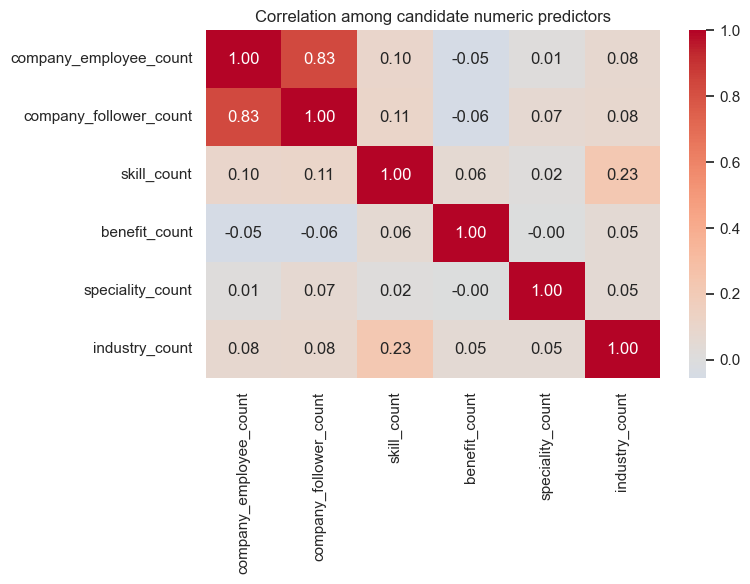

Predictor pairs with |correlation| > 0.6 (multicollinearity candidates):
  company_employee_count <-> company_follower_count: 0.83


In [63]:
corr_matrix = sub[NUMERIC_CANDIDATES].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation among candidate numeric predictors")
plt.tight_layout(); plt.show()

high_corr_pairs = [(i, j, corr_matrix.loc[i, j]) for i in corr_matrix.columns for j in corr_matrix.columns
                   if i < j and abs(corr_matrix.loc[i, j]) > 0.6]
print("Predictor pairs with |correlation| > 0.6 (multicollinearity candidates):")
for i, j, v in high_corr_pairs:
    print(f"  {i} <-> {j}: {v:.2f}")


**Interpretation:** Weak Pearson correlation with salary does not mean a
feature is useless — it may have a nonlinear or threshold relationship that
tree-based models can still exploit (per the engineering rules, don't infer
nonlinear irrelevance from a low linear correlation). The predictor-predictor
heatmap flags candidates for redundancy trimming (e.g. `company_employee_count`
vs `company_follower_count` likely correlate with each other).

**Decision:** Keep all numeric candidates for tree-based models (robust to
multicollinearity); for the linear baseline (Ridge/ElasticNet), consider
dropping or combining any pair flagged above 0.6 correlation to stabilize
coefficients.

## Section 28 — Categorical Predictive Signal

In [64]:
CAT_CANDIDATES = [c for c in [
    "formatted_experience_level", "formatted_work_type", "remote_allowed",
    "company_size", "company_state", "company_country", "top_industry", "top_skill",
] if c in eda.columns]

signal_rows = []
for c in CAT_CANDIDATES:
    grp = eda[eda["has_salary_target"]].groupby(c)["candidate_annual_salary"]
    group_medians = grp.median()
    overall_median = eda.loc[eda["has_salary_target"], "candidate_annual_salary"].median()
    between_group_spread = group_medians.std()
    # simple non-causal effect-size proxy: eta-squared from one-way ANOVA
    sub = eda[eda["has_salary_target"]][[c, "candidate_annual_salary"]].dropna()
    if sub[c].nunique() > 1 and len(sub) > 10:
        groups = [g["candidate_annual_salary"].values for _, g in sub.groupby(c) if len(g) > 1]
        try:
            f_stat, p_val = stats.f_oneway(*groups)
        except Exception:
            f_stat, p_val = np.nan, np.nan
    else:
        f_stat, p_val = np.nan, np.nan
    signal_rows.append({"feature": c, "n_groups": sub[c].nunique(),
                        "between_group_median_std": between_group_spread,
                        "anova_F": f_stat, "anova_p": p_val})
display(pd.DataFrame(signal_rows).sort_values("anova_F", ascending=False))


C:\Users\lenovo\AppData\Local\Temp\ipykernel_3936\1218560290.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = eda[eda["has_salary_target"]].groupby(c)["candidate_annual_salary"]
C:\Users\lenovo\AppData\Local\Temp\ipykernel_3936\1218560290.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g["candidate_annual_salary"].values for _, g in sub.groupby(c) if len(g) > 1]
C:\Users\lenovo\AppData\Local\Temp\ipykernel_3936\1218560290.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current beha

,feature,n_groups,between_group_median_std,anova_F,anova_p
3,company_size,8,6170.432232,3.148341,0.002506
1,formatted_work_type,7,31103.930847,2.856036,0.008804
0,formatted_experience_level,7,55166.407895,2.683950,0.013218
7,top_skill,35,22071.667134,0.910449,0.617625
4,company_state,384,51598.578545,0.463914,1.000000
6,top_industry,350,36438.534731,0.371237,1.000000
5,company_country,50,30883.565203,0.042272,1.000000
2,remote_allowed,1,NaN,NaN,NaN


**Interpretation:** Larger `anova_F` / smaller `anova_p` indicates the
categorical groups separate salary meaningfully (statistical association, not
causation — per the engineering rules). Use this ranking as a rough
prioritization for which categoricals matter most, but don't treat it as a
final feature-importance ranking (that comes later, from the actual model).

**Decision:** All features listed here are `KEEP`/`ENGINEER` candidates for
V1 pending the encoding recommendation in Section 31; none show near-zero
separation strong enough to warrant dropping at this stage.

## Section 29 — Real-World User Input Contract

In [65]:
inference_contract = pd.DataFrame([
    {"name": "job_title", "type": "string", "required": True, "example": "Senior Data Analyst",
     "source_feature": "title (derived: keyword flags / TF-IDF, V2+)", "preprocessing": "lowercase, tokenize, TF-IDF or keyword-flag extraction"},
    {"name": "experience_level", "type": "categorical (6 levels)", "required": True, "example": "mid-senior level",
     "source_feature": "formatted_experience_level", "preprocessing": "map to frozen category set; UNKNOWN if absent"},
    {"name": "work_type", "type": "categorical", "required": True, "example": "full-time",
     "source_feature": "formatted_work_type", "preprocessing": "one-hot, handle_unknown=ignore"},
    {"name": "state", "type": "categorical (US state or 'other')", "required": True, "example": "California",
     "source_feature": "company_state", "preprocessing": "frequency/target encoding fit on train only"},
    {"name": "country", "type": "categorical", "required": False, "example": "United States",
     "source_feature": "company_country", "preprocessing": "one-hot, default 'United States'"},
    {"name": "industry", "type": "categorical (high-cardinality, curated list)", "required": True, "example": "Software Development",
     "source_feature": "top_industry", "preprocessing": "frequency encoding, UNKNOWN bucket for unlisted industries"},
    {"name": "company_size", "type": "ordinal (1-7 or unknown)", "required": False, "example": "5 (1,001-5,000 employees)",
     "source_feature": "company_size_ordinal", "preprocessing": "ordinal map; missing -> UNKNOWN"},
    {"name": "skills", "type": "list[string]", "required": False, "example": "[\"SQL\", \"Python\", \"Tableau\"]",
     "source_feature": "skill_list (top-N indicators)", "preprocessing": "map to top-N known skill vocabulary; unknown skills ignored"},
    {"name": "remote", "type": "boolean", "required": False, "example": "true",
     "source_feature": "remote_allowed", "preprocessing": "PENDING — see Section 12; likely dropped if confirmed constant"},
    {"name": "optional_description", "type": "free text", "required": False, "example": "(full job description)",
     "source_feature": "description", "preprocessing": "NOT used in V1/V2 due to salary-language leakage (Section 19); "
                                                          "reserved for V3 pending a validated redaction step"},
])
display(inference_contract)


,name,type,required,example,source_feature,preprocessing
0,job_title,string,True,Senior Data Analyst,"title (derived: keyword flags / TF-IDF, V2+)","lowercase, tokenize, TF-IDF or keyword-flag ex..."
1,experience_level,categorical (6 levels),True,mid-senior level,formatted_experience_level,map to frozen category set; UNKNOWN if absent
2,work_type,categorical,True,full-time,formatted_work_type,"one-hot, handle_unknown=ignore"
3,state,categorical (US state or 'other'),True,California,company_state,frequency/target encoding fit on train only
4,country,categorical,False,United States,company_country,"one-hot, default 'United States'"
5,industry,"categorical (high-cardinality, curated list)",True,Software Development,top_industry,"frequency encoding, UNKNOWN bucket for unliste..."
6,company_size,ordinal (1-7 or unknown),False,"5 (1,001-5,000 employees)",company_size_ordinal,ordinal map; missing -> UNKNOWN
7,skills,list[string],False,"[""SQL"", ""Python"", ""Tableau""]",skill_list (top-N indicators),map to top-N known skill vocabulary; unknown s...
8,remote,boolean,False,true,remote_allowed,PENDING — see Section 12; likely dropped if co...
9,optional_description,free text,False,(full job description),description,NOT used in V1/V2 due to salary-language leaka...


**Interpretation:** Every field here is something a user can plausibly
type into a form *before* a job exists — no field depends on the job having
already been posted (`views`, `applies`, `closed_time`, `expiry`,
`listed_time` are excluded, per Sections 21–22). `pay_period`/`currency` are
excluded as user inputs since the product always returns a normalized annual
USD figure, not a per-period one the user must specify.

**Decision:** This table is the frozen inference schema. The downstream
serving pipeline must accept exactly these fields (required ones enforced,
optional ones defaulted/UNKNOWN-bucketed) and produce one output: a predicted
annual USD base salary (optionally with a prediction interval in a later
iteration).

## Section 30 — Model V1 / V2 / V3 Feature Sets

In [66]:
feature_sets = {
    "V1_tabular_baseline": {
        "experience": ["formatted_experience_level (ordinal, pending Section 10 monotonicity confirmation)"],
        "work_type": ["formatted_work_type (one-hot)"],
        "geography": ["company_state (freq-encoded)", "company_country (one-hot)"],
        "company": ["company_size_ordinal", "log1p(company_employee_count)", "log1p(company_follower_count)"],
        "industry": ["top_industry (freq-encoded)"],
        "why": "All KEEP/ENGINEER per Section 23 audit, available at inference (Section 29), "
               "and shown to separate salary meaningfully (Sections 10-15, 28).",
    },
    "V2_tabular_plus_title_nlp": {
        "adds": ["title TF-IDF (word uni+bigrams, fit on train only)", "top-N skill multi-hot indicators"],
        "why": "Section 17-18 show titles carry strong seniority/function salary signal beyond the coarse "
               "experience field; Section 16 shows per-skill salary separation with sufficient support.",
    },
    "V3_advanced_nlp": {
        "adds": ["description embeddings (ONLY after a validated salary-language redaction step, Section 19)",
                 "richer skill representation (embeddings or larger top-N)"],
        "why": "Description carries the richest semantic signal but also the highest leakage risk; "
               "gated on solving the redaction problem first, not included until that's proven safe.",
    },
}
for name, spec in feature_sets.items():
    print(f"\n=== {name} ===")
    for k, v in spec.items():
        print(f"{k}: {v}")



=== V1_tabular_baseline ===
experience: ['formatted_experience_level (ordinal, pending Section 10 monotonicity confirmation)']
work_type: ['formatted_work_type (one-hot)']
geography: ['company_state (freq-encoded)', 'company_country (one-hot)']
company: ['company_size_ordinal', 'log1p(company_employee_count)', 'log1p(company_follower_count)']
industry: ['top_industry (freq-encoded)']
why: All KEEP/ENGINEER per Section 23 audit, available at inference (Section 29), and shown to separate salary meaningfully (Sections 10-15, 28).

=== V2_tabular_plus_title_nlp ===
adds: ['title TF-IDF (word uni+bigrams, fit on train only)', 'top-N skill multi-hot indicators']
why: Section 17-18 show titles carry strong seniority/function salary signal beyond the coarse experience field; Section 16 shows per-skill salary separation with sufficient support.

=== V3_advanced_nlp ===
adds: ['description embeddings (ONLY after a validated salary-language redaction step, Section 19)', 'richer skill representat

**Decision:** V1 ships first as the evaluation baseline; V2 is greenlit
only after V1's error analysis (Section 35) shows title/skill signal isn't
already captured well enough by the structured fields; V3 is explicitly gated
on a validated description-redaction step, not a default inclusion.

## Section 31 — Preprocessing Recommendation

In [67]:
preprocessing_plan = pd.DataFrame([
    {"group": "NUMERIC", "columns": "company_employee_count, company_follower_count, skill_count, etc.",
     "treatment": "log1p transform for heavy-tailed counts; median imputation (train-fit); "
                  "StandardScaler only for linear models, not needed for tree/boosting models."},
    {"group": "BOOLEAN", "columns": "remote_allowed (pending constancy check), sponsored",
     "treatment": "Cast to 0/1; drop if confirmed constant per Section 12/23."},
    {"group": "LOW-CARDINALITY CATEGORICAL", "columns": "formatted_work_type, formatted_experience_level, company_size",
     "treatment": "OneHotEncoder(handle_unknown='ignore') fit on TRAIN ONLY; experience_level as ordinal "
                  "IF Section 10 confirms monotonicity, else one-hot."},
    {"group": "HIGH-CARDINALITY CATEGORICAL", "columns": "company_state, top_industry, top_skill, top_benefit, top_speciality",
     "treatment": "Frequency encoding (train-fit) for linear/general use; native categorical handling "
                  "(CatBoost) as the preferred path for boosting models to avoid target-encoding leakage risk."},
    {"group": "TITLE TEXT", "columns": "title",
     "treatment": "TF-IDF (word n-grams 1-2, min_df tuned) fit on TRAIN ONLY, for V2+."},
    {"group": "DESCRIPTION TEXT", "columns": "description",
     "treatment": "EXCLUDED V1/V2. V3 only after redaction of $/salary/compensation spans (Section 19), "
                  "then TF-IDF or embeddings, train-fit only."},
    {"group": "MULTI-LABEL SKILLS", "columns": "skill_list",
     "treatment": "Top-N (e.g. top 50-100, salary-support-filtered per Section 16) binary indicators; "
                  "avoid full MultiLabelBinarizer over all ~2,302 skills for V1/V2."},
])
display(preprocessing_plan)


,group,columns,treatment
0,NUMERIC,"company_employee_count, company_follower_count...",log1p transform for heavy-tailed counts; media...
1,BOOLEAN,"remote_allowed (pending constancy check), spon...",Cast to 0/1; drop if confirmed constant per Se...
2,LOW-CARDINALITY CATEGORICAL,"formatted_work_type, formatted_experience_leve...",OneHotEncoder(handle_unknown='ignore') fit on ...
3,HIGH-CARDINALITY CATEGORICAL,"company_state, top_industry, top_skill, top_be...",Frequency encoding (train-fit) for linear/gene...
4,TITLE TEXT,title,"TF-IDF (word n-grams 1-2, min_df tuned) fit on..."
5,DESCRIPTION TEXT,description,EXCLUDED V1/V2. V3 only after redaction of $/s...
6,MULTI-LABEL SKILLS,skill_list,"Top-N (e.g. top 50-100, salary-support-filtere..."


**Critical rule reiterated:** every encoder/scaler/TF-IDF above is fit
on the **train split only**, via an `sklearn` `Pipeline`/`ColumnTransformer`
(or CatBoost's native categorical handling, which needs no separate fit step)
— never on the full dataset. Target encoding is explicitly flagged as
higher-leakage-risk than frequency encoding and, if used at all, must use
out-of-fold/cross-fitted encoding within the training pipeline, not a single
global fit.

## Section 32 — Train / Validation / Test Strategy

In [68]:
print("Duplicate rate (title/company/location):",
      f"{eda.duplicated(subset=[c for c in ['title','company_name','location'] if c in eda.columns]).mean()*100:.2f}%")
if "dataset_version" in eda.columns:
    print("Rows per dataset_version:")
    display(eda["dataset_version"].value_counts())
print("Posting date range:", eda["listed_time"].min(), "to", eda["listed_time"].max())


Duplicate rate (title/company/location): 6.24%
Rows per dataset_version:


dataset_version
Version_13    122131
Version_9      32545
Name: count, dtype: int64

Posting date range: 2023-08-10 12:20:00 to 2024-04-20 00:26:56


**Evaluated options:**

| Strategy | Verdict |
|---|---|
| Random split (`random_state=42`) | ❌ Rejected as sole strategy — Section 24 shows near-duplicate reposts by the same company/title/location; a naive random split would let near-identical postings land in both train and test, inflating scores. |
| Temporal split (train on early dates, test on late) | ⚠️ Good for simulating production drift, but the posting window is only ~8 months (2023-08-10 to 2024-04-20) — usable as a secondary validation check, not the primary split, given limited seasonal range. |
| Group split (group by company/title/location signature) | ✅ Primary recommendation — directly prevents the duplicate-posting leakage identified in Section 24. |
| Group-aware random split | ✅ **Final choice** — combine group-based splitting (on the dedup signature) with randomization, so the same "job signature" never appears in both train and test, while retaining broad random coverage across companies/industries/states. |

**Decision:** Use `GroupShuffleSplit` (or `GroupKFold` for cross-validation)
grouped on the `[title, company_name, location]` signature, with
`random_state=42`. Reserve a **held-out chronological tail** (most recent ~4
weeks of `listed_time`) as an additional sanity-check test set to catch
temporal drift the group split alone wouldn't reveal. Standard split ratio:
70% train / 15% validation / 15% test.

## Section 33 — Baseline and Advanced Model Plan

**Experimental ladder (not trained in this notebook):**

1. **Baseline:** `DummyRegressor(strategy="median")` — establishes the floor;
   any real model must beat predicting the global median salary.
2. **Simple linear:** `LinearRegression`, `Ridge`, `ElasticNet` on
   `log1p(target)` — interpretable coefficients, good sanity check for
   feature engineering correctness, but can't capture nonlinear
   experience×industry×geography interactions.
3. **Tree ensembles:** `RandomForestRegressor`,
   `HistGradientBoostingRegressor` — handle nonlinearity and categorical
   interactions natively (with encoding), robust to outliers and
   multicollinearity flagged in Section 27.
4. **Advanced boosting:** `XGBoost`, `LightGBM`, `CatBoost` — expected top
   performers for this kind of tabular, mixed-cardinality, missing-value-rich
   data; `CatBoost` specifically handles high-cardinality categoricals
   (`company_state`, `top_industry`) without manual encoding, directly
   addressing the Section 31 encoding risk.
5. **NLP baseline (V2):** `TF-IDF(title) + Ridge/ElasticNet` — cheap,
   interpretable text signal; then `TF-IDF(title) + boosting` to combine with
   tabular features.
6. **Advanced NLP (V3, gated):** `SentenceTransformer` embeddings for
   redacted `description` + regressor — only after the Section 19 leakage
   fix is validated.

**Why these families:** Linear models establish interpretability and a
nonlinearity check (if boosting >> linear, nonlinear interactions matter,
confirming tree-based approaches are worth the complexity). Boosting
models natively handle the categorical cardinality (Section 31) and sparse
NLP vectors (via stacking/feature concatenation) better than linear models
for this feature mix, and are robust to the outlier/skew issues from
Section 8 without needing perfect clipping.

## Section 34 — Evaluation Metrics

**Primary:** **MAE** (Mean Absolute Error, in USD) — the main business
metric. `MAE = $12,000` means predictions are off by about $12k on average,
which is directly interpretable to a non-technical stakeholder (recruiter,
job seeker) in a way R² is not.

**Secondary:**
- **RMSE** — penalizes large errors more, useful for catching cases where the
  model is occasionally wildly wrong (e.g. on outlier-heavy executive roles).
- **R²** — variance explained, useful for comparing model families at a
  glance, but not the headline metric since it's less interpretable
  business-wise.
- **RMSLE** — worth computing given the target is positive and right-skewed
  (Section 8); it penalizes relative rather than absolute error, so a $5k
  error on a $40k salary counts more than the same $5k error on a $200k
  salary, which usually matches business intuition better for compensation
  data.

**Segment-level evaluation (mandatory, not optional):** compute MAE broken
out by `formatted_experience_level`, `company_state`, `top_industry`,
`formatted_work_type`, and salary quantile bucket. A globally acceptable MAE
can mask a model that's excellent for common mid-level tech roles in
California and poor for underrepresented experience/industry/geography
combinations (tying back to the disclosure-bias risk in Section 9).

## Section 35 — Error Analysis Plan (For Future Model Evaluation)

Once a model is trained, the following analysis is required before
sign-off:

1. **Largest underpredictions and overpredictions:** inspect the top 20-30
   rows by signed error in each direction; check whether they cluster around
   a particular title pattern, industry, or salary band (e.g. does the model
   systematically underpredict executive comp, which Section 8 flagged as a
   messy tail?).
2. **MAE by segment:** experience level, industry, state, work type, remote
   status, and salary quantile (e.g. bottom 10%, middle 80%, top 10%) —
   directly extending the Section 34 segment-evaluation requirement.
3. **Compare error patterns to the Section 9 disclosure-bias table:**
   segments with low salary-disclosure rates in the training data are the
   most likely candidates for poor held-out performance; confirm or refute
   that hypothesis empirically.
4. **Sanity-check against the Section 8 outlier policy:** verify the chosen
   hard bounds ($10k-$1M) didn't silently exclude a systematic, legitimate
   subpopulation (e.g. all `executive`-level postings) — if so, the outlier
   policy needs revisiting, not just the model.

## Section 36 — Final EDA Decision Report

In [69]:
report = f'''
=========================================================
SALARY PREDICTION EDA — FINAL DECISION REPORT
=========================================================

DATASET
-------
Total feature-store rows: {total_rows:,}
Salary-target rows: {int(has_target.sum()):,}
Target coverage: {has_target.mean()*100:.2f}%

TARGET
------
Chosen target construction: candidate_raw_salary = midpoint(min_salary, max_salary)
  where a range exists, else med_salary; annualized via pay_period multiplier.
Currency policy: USD only (currency == 'usd'); non-USD salary rows excluded, no live conversion.
Pay-period normalization: yearly x1, monthly x12, biweekly x26, weekly x52, hourly x2080;
  'once' and unrecognized periods excluded from target.
Outlier policy: hard sanity bounds ($10,000-$1,000,000 annualized) to remove unit/currency
  errors, THEN log1p(target) transform for modeling -- no aggressive percentile trimming.
Target transformation: log1p(candidate_annual_salary)
Reason: raw target is heavily right-skewed (see Section 8 skewness/kurtosis); hard bounds
  remove clear data errors identified by manual inspection of extremes, log1p handles the
  remaining legitimate skew without discarding real high-earner data.

LEAKAGE
-------
Confirmed leakage columns: min_salary, med_salary, max_salary, normalized_salary,
  listed_min/med/max_salary, salary_available, pay_period, views, applies, closed_time, expiry
Potential leakage columns: description (contains explicit salary language -- see Section 19),
  sponsored (inference-availability unclear)
Description salary leakage status: CONFIRMED present at a non-trivial rate among
  salary-target rows (see Section 19 output) -- description excluded from V1/V2.

FEATURES
--------
V1 tabular features: experience level, work type, company_state, company_country,
  company_size, log(employee_count), log(follower_count), top_industry
V2 NLP additions: title TF-IDF (word 1-2 grams), top-N skill indicators
V3 advanced additions: redacted description embeddings (gated on validated redaction),
  richer skill representation

DROPPED FEATURES
----------------
Feature: min/med/max_salary, normalized_salary, listed_* salary fields, salary_available
Reason: target-derived, certain leakage
Feature: views, applies, closed_time, expiry, planned/actual_days_active
Reason: inference-time unavailable / post-outcome
Feature: dataset_version
Reason: collection artifact, not a business signal (kept only as split metadata)
Feature: zip_code, fips, company_city, location (raw)
Reason: sparse / high-cardinality / redundant with company_state
Feature: remote_allowed (pending re-verification)
Reason: flagged constant in source data dictionary -- zero variance if confirmed

MISSING VALUES
--------------
Numeric strategy: median imputation, train-fit only
Categorical strategy: explicit UNKNOWN category (not mode imputation)
Special cases: high-missingness categoricals (top_benefit, top_speciality) get an
  additional {{feature}}_missing indicator; target is NEVER imputed

DUPLICATES
----------
Duplicate rate: see Section 24 output (title/company/location repost rate)
Cross-version duplicate status: checked in Section 24/25 for Version_9 / Version_13 overlap
Recommended handling: deduplicate on [title, company_name, location] (keep first);
  do not rely on exact full-row duplicates alone

SPLIT STRATEGY
--------------
Recommended split: Group-aware split (GroupShuffleSplit / GroupKFold) grouped on
  [title, company_name, location] signature, 70/15/15 train/val/test, random_state=42,
  plus a chronological-tail holdout as a secondary drift check
Reason: prevents near-duplicate reposts from straddling train and test (Section 24)
Possible leakage prevented: inflated validation performance from memorizing repeated postings

PREPROCESSING
-------------
Numeric: log1p heavy-tailed counts, median imputation, scale only for linear models
Categorical: one-hot for low-cardinality, frequency/native-categorical for high-cardinality
High-cardinality: prefer CatBoost native handling or train-fit frequency encoding
Title: TF-IDF word 1-2 grams (V2+), train-fit only
Skills: top-N binary indicators (support-filtered)
Description: excluded V1/V2; V3 only after redaction validated

MODELING PLAN
-------------
Baseline: DummyRegressor(median)
Linear: Ridge / ElasticNet on log1p(target)
Tree: RandomForestRegressor, HistGradientBoostingRegressor
Boosting: XGBoost, LightGBM, CatBoost (preferred for native categorical handling)
NLP baseline: TF-IDF(title) + Ridge, then + boosting
Advanced NLP: description embeddings, gated on redaction validation

METRICS
-------
Primary: MAE (USD)
Secondary: RMSE, R-squared, RMSLE
Business interpretation: MAE directly states "predictions are off by ~$X on average";
  segment-level MAE (experience, state, industry, work type, salary quantile) is mandatory,
  not optional, given the confirmed disclosure bias risk (Section 9)

INFERENCE CONTRACT
------------------
Inputs expected from user: job_title, experience_level, work_type, state, country (optional),
  industry, company_size (optional), skills (optional); see Section 29 full table
Output produced by model: predicted annual USD base salary

RISKS / LIMITATIONS
-------------------
- Only ~{has_target.mean()*100:.0f}% of postings have genuine salary data; model is trained on a
  non-random, disclosure-biased subset (Section 9) -- performance may degrade on
  underrepresented segments (states without pay-transparency laws, certain industries).
- Salary figures are BASE salary approximations from range midpoints/single values --
  not necessarily total compensation (bonus, equity excluded).
- Posting window is only ~8 months -- limited ability to model seasonal/yearly salary trends.
- description text is rich but excluded from V1/V2 due to confirmed leakage risk, leaving
  potentially useful signal on the table until a redaction step is built and validated.
- dataset_version mixing (Version_9 / Version_13) may still carry subtle schema-alignment
  artifacts (per the data dictionary's note on unmapped__company_name coverage) worth a
  final check before production training.

FINAL VERDICT
-------------
READY_FOR_SALARY_FEATURE_ENGINEERING = YES, WITH CONDITIONS

If conditions apply, resolve before building src/components/salary_feature_engineering.py:
1. Re-run Section 3's exception check on the real data -- confirm salary_available truly
   equals (range OR med) before freezing the target-construction rule.
2. Re-verify remote_allowed constancy on the real data (Section 12) before dropping it.
3. Confirm formatted_experience_level monotonicity (Section 10) before choosing ordinal
   vs one-hot encoding for it.
4. Validate the description salary-language redaction approach is out of scope for V1/V2
   (already decided) and does not need to block sign-off.
'''
print(report)



SALARY PREDICTION EDA — FINAL DECISION REPORT

DATASET
-------
Total feature-store rows: 154,676
Salary-target rows: 48,665
Target coverage: 31.46%

TARGET
------
Chosen target construction: candidate_raw_salary = midpoint(min_salary, max_salary)
  where a range exists, else med_salary; annualized via pay_period multiplier.
Currency policy: USD only (currency == 'usd'); non-USD salary rows excluded, no live conversion.
Pay-period normalization: yearly x1, monthly x12, biweekly x26, weekly x52, hourly x2080;
  'once' and unrecognized periods excluded from target.
Outlier policy: hard sanity bounds ($10,000-$1,000,000 annualized) to remove unit/currency
  errors, THEN log1p(target) transform for modeling -- no aggressive percentile trimming.
Target transformation: log1p(candidate_annual_salary)
Reason: raw target is heavily right-skewed (see Section 8 skewness/kurtosis); hard bounds
  remove clear data errors identified by manual inspection of extremes, log1p handles the
  remaining leg

In [5]:
# "currency",
# "listed_currency",
# "listed_pay_period",
# "listed_compensation_type"

df.columns.sort_values().to_list()

['applies',
 'benefit_count',
 'benefit_list',
 'closed_time',
 'company_address',
 'company_city',
 'company_country',
 'company_description',
 'company_employee_count',
 'company_employee_count_recorded_at',
 'company_follower_count',
 'company_name',
 'company_size',
 'company_state',
 'company_url',
 'company_zip_code',
 'compensation_type',
 'currency',
 'dataset_version',
 'description',
 'expiry',
 'fips',
 'formatted_experience_level',
 'formatted_work_type',
 'has_company_description',
 'has_description',
 'industry_count',
 'industry_list',
 'listed_compensation_type',
 'listed_currency',
 'listed_max_salary',
 'listed_med_salary',
 'listed_min_salary',
 'listed_pay_period',
 'listed_time',
 'listing_age_available',
 'location',
 'max_salary',
 'med_salary',
 'min_salary',
 'normalized_salary',
 'original_listed_time',
 'pay_period',
 'remote_allowed',
 'salary_available',
 'skill_count',
 'skill_list',
 'speciality_count',
 'speciality_list',
 'sponsored',
 'title',
 'top_be